# AI Fairness Project: Student Dropout Risk Model


Project framing:
1. The university wants to identify students at risk of dropping out **before semester 2 starts**
2. We therefore remove the `Enrolled` class and model `Dropout` vs `Graduate`
3. We keep only information available before semester 2, so all `2nd sem` variables are removed
4. False negatives are especially costly, because they correspond to at-risk students who are not flagged for support
5. The fairness objective is to identify groups that may be **underflagged**, which means group differences in False Negative Rate matter most


> [Recap & Setup](#Recap-&-Setup)  
> [Helper Functions](#Helper-Functions)  
> [Data Loading & Train/Test Split](#Data-Loading-&-Train/Test-Split)  
> [Exploratory Data Analysis](#Exploratory-Data-Analysis)  
> [Model Training: Logistic Regression](#Model-Training:-Logistic-Regression)  
> [Model Training: XGBoost](#Model-Training:-XGBoost)  
> [LR vs. XGBoost: Performance Summary](#LR-vs.-XGBoost:-Performance-Summary)  
> [Operational Threshold Selection](#Operational-Threshold-Selection)  
> [Bias Audit](#Bias-Audit)  
> [Mitigation: Pre-processing — Reweighing](#Mitigation:-Pre-processing-—-Reweighing)  
> [Mitigation: In-processing — ExponentiatedGradient](#Mitigation:-In-processing-—-ExponentiatedGradient)  
> [Mitigation: Post-processing — ThresholdOptimizer](#Mitigation:-Post-processing-—-ThresholdOptimizer)  
> [Comparing Mitigation Techniques](#Comparing-Mitigation-Techniques)  
> [XGBoost Post-hoc Explainability](#XGBoost-Post-hoc-Explainability)  
> [Model Card](#Model-Card)


# Recap & Setup

- train an interpretable Logistic Regression baseline
- train a stronger nonlinear XGBoost comparator
- audit group disparities with `MetricFrame`
- apply three mitigation families
- compare fairness gains against performance trade-offs
- the outcome is `Dropout` 
- the harm is **missed intervention**
- the most important fairness metric is therefore **False Negative Rate**
- we use the sensitive attributes selected for this project:
  - `gender_group`
  - `debtor_group`
  - `scholarship_group`
  - `displaced_group`
  - `age_group`


In [47]:
# General
import os
import warnings
from datetime import date
from io import BytesIO
import base64

# Data
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Statistical modelling / multicollinearity diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# AIF360
from aif360.sklearn.preprocessing import ReweighingMeta, Reweighing

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, roc_auc_score,
    roc_curve, auc, confusion_matrix, balanced_accuracy_score,
    precision_recall_curve, classification_report, precision_score, fbeta_score
)
from sklearn import set_config

# XGBoost
from xgboost import XGBClassifier

# Fairlearn
from fairlearn.metrics import (
    MetricFrame, true_positive_rate, false_positive_rate,
    false_negative_rate, selection_rate, count,
    false_negative_rate_difference
)
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# IPython display
from IPython.display import display, Markdown

set_config(display="diagram")
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

random_seed = 445
np.random.seed(random_seed)


## Helper Functions


In [48]:
def import_student_data(path="dataset.csv"):
    """
    Load the student dataset and apply the project-specific problem framing:
    1. remove Enrolled
    2. create binary target where 1 = Dropout
    3. remove all second-semester variables
    4. create fairness groups used later in the audit
    """
    df = pd.read_csv(path)
    df = df[df["Target"] != "Enrolled"].copy()
    df["target"] = (df["Target"] == "Dropout").astype(int)

    second_sem_cols = [c for c in df.columns if "2nd sem" in c]
    df = df.drop(columns=second_sem_cols).copy()

    # Readable fairness groups for the audit and mitigation sections.
    df["gender_group"] = df["Gender"].map({0: "Female", 1: "Male"}).fillna("Other")
    df["debtor_group"] = df["Debtor"].map({0: "Not debtor", 1: "Debtor"}).fillna("Unknown")
    df["scholarship_group"] = df["Scholarship holder"].map({0: "No scholarship", 1: "Scholarship holder"}).fillna("Unknown")
    df["displaced_group"] = df["Displaced"].map({0: "Not displaced", 1: "Displaced"}).fillna("Unknown")
    df["age_group"] = pd.cut(
        df["Age at enrollment"],
        bins=[-np.inf, 19, 23, np.inf],
        labels=["<=19", "20-23", "24+"],
    )
    return df, second_sem_cols


def column_summary(df):
    summary = pd.DataFrame(index=df.columns)
    summary["dtype"] = df.dtypes.astype(str)
    summary["missing"] = df.isna().sum()
    summary["missing_%"] = (df.isna().mean() * 100).round(2)
    summary["unique"] = df.nunique(dropna=True)

    numeric_cols = df.select_dtypes(include="number").columns
    summary.loc[numeric_cols, "mean"] = df[numeric_cols].mean()
    summary.loc[numeric_cols, "std"] = df[numeric_cols].std()
    summary.loc[numeric_cols, "median"] = df[numeric_cols].median()
    return summary


def iterative_vif_filter(X, threshold=5.0, protected_cols=None):
    """
    Iteratively remove the variable with the highest VIF until all remaining
    variables have VIF <= threshold.
    Columns listed in protected_cols are never dropped automatically.
    """
    protected_cols = [] if protected_cols is None else list(protected_cols)
    cols = list(X.columns)
    removed = []

    while True:
        vif_vals = [variance_inflation_factor(X[cols].values, i) for i in range(len(cols))]
        vif_map = dict(zip(cols, vif_vals))
        non_protected = [c for c in cols if c not in protected_cols]
        if not non_protected:
            break

        candidate_vifs = {c: vif_map[c] for c in non_protected}
        feature_to_drop = max(candidate_vifs, key=candidate_vifs.get)
        max_vif = candidate_vifs[feature_to_drop]
        if max_vif <= threshold:
            break

        removed.append({"feature": feature_to_drop, "vif": max_vif})
        cols.remove(feature_to_drop)

    final_vif = pd.DataFrame({
        "feature": cols,
        "vif": [variance_inflation_factor(X[cols].values, i) for i in range(len(cols))]
    }).sort_values("vif", ascending=False)

    removed_df = pd.DataFrame(removed).sort_values("vif", ascending=False) if removed else pd.DataFrame(columns=["feature", "vif"])
    return cols, removed_df, final_vif


def plot_roc_pr(X, Y, model, title=""):
    """Plot ROC curve and Precision-Recall curve for a fitted model."""
    y_proba = model.predict_proba(X)[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ROC
    fpr, tpr, _ = roc_curve(Y, y_proba)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, ls="--", label=f"AUC = {roc_auc_val:.2f}")
    axes[0].plot([0, 1], [0, 1], c="r", label="Random = 0.5")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve {title}")
    axes[0].legend(loc="lower right")

    # PR
    precision, recall, threshold = precision_recall_curve(Y, y_proba)
    pr_df = pd.DataFrame({"threshold": threshold, "recall": recall[1:], "precision": precision[1:]})
    pr_melted = pd.melt(pr_df, id_vars=["threshold"], value_vars=["recall", "precision"])
    sns.lineplot(x="threshold", y="value", hue="variable", data=pr_melted, ax=axes[1])
    axes[1].set_title(f"Precision-Recall Curve {title}")

    plt.tight_layout()
    plt.show()


def eval_binary_classifier(model, x, y, labels=("Graduate", "Dropout")):
    """
    Visualise classifier performance: confusion matrix, prediction
    distributions, and ROC curve. Returns F1 score.
    """
    p = model.predict_proba(x)
    if len(model.classes_) != 2:
        raise ValueError("Binary classification only")
    pos_p = p[:, 1] if model.classes_[1] == 1 else p[:, 0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Confusion matrix
    cm = confusion_matrix(y, model.predict(x))
    sns.heatmap(cm, annot=True, cmap="Blues", cbar=False, fmt="g", ax=axes[0],
                annot_kws={"size": 14})
    cm_labels = ["True Negatives", "False Positives", "False Negatives", "True Positives"]
    for i, t in enumerate(axes[0].texts):
        t.set_text(t.get_text() + "\n" + cm_labels[i])
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # Prediction distributions
    df_p = pd.DataFrame({"probPos": pos_p, "target": y})
    axes[1].hist(df_p[df_p.target == 1].probPos, density=True, bins=25, alpha=.5, color="green", label=labels[1])
    axes[1].hist(df_p[df_p.target == 0].probPos, density=True, bins=25, alpha=.5, color="red", label=labels[0])
    axes[1].axvline(.5, color="blue", linestyle="--", label="Boundary")
    axes[1].set_xlim([0, 1])
    axes[1].set_title("Prediction Distributions")
    axes[1].set_xlabel("Positive Probability")
    axes[1].legend(loc="upper right")

    # ROC
    tn, fp, fn, tp = cm.ravel()
    fp_rates, tp_rates, _ = roc_curve(y, p[:, 1])
    roc_auc_val = auc(fp_rates, tp_rates)
    axes[2].plot(fp_rates, tp_rates, color="green", lw=1, label=f"AUC = {roc_auc_val:.2f}")
    axes[2].plot([0, 1], [0, 1], lw=1, linestyle="--", color="grey")
    axes[2].plot(fp / (fp + tn), tp / (tp + fn), "bo", markersize=8, label="Decision Point")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_title("ROC Curve")
    axes[2].legend(loc="lower right")

    plt.subplots_adjust(wspace=.3)
    plt.show()

    precision_val = tp / (tp + fp)
    recall_val = tp / (tp + fn)
    f1 = 2 * (precision_val * recall_val) / (precision_val + recall_val)
    print(f"Precision: {precision_val:.2f} | Recall: {recall_val:.2f} | F1: {f1:.2f}")
    return f1


def threshold_table(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "threshold": round(float(t), 2),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
            "fnr": fn / (fn + tp) if (fn + tp) else np.nan,
            "tnr": tn / (tn + fp) if (tn + fp) else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["f2", "recall"], ascending=False).reset_index(drop=True)


def plot_technique_comparison(mf_dict, metric, title_suffix=""):
    """
    Bar chart comparing a metric across mitigation techniques,
    grouped by sensitive feature value.
    """
    data = {k: v.by_group[metric] for k, v in mf_dict.items()}
    comparison_df = pd.DataFrame.from_dict(data)
    ax = comparison_df.plot.bar(figsize=(10, 5))
    ax.set_title(f"{metric} — {title_suffix}")
    ax.set_xlabel("Group")
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Data Loading & Train/Test Split

We load the student dataset, apply the project framing, set the sensitive attributes as the DataFrame index, and perform a **stratified 70/30 train/test split**.

Why these steps matter:
1. `Enrolled` is removed because the problem is a binary intervention problem: `Dropout` vs `Graduate`
2. All second-semester columns are removed because they would leak future information
3. We set the sensitive features as index 
4. The split is stratified so the class imbalance is preserved in both train and test sets


All `2nd sem` variables are removed because the university wants to intervene **before** semester 2 starts, so using second-semester information would leak future outcomes into the model. T


In [49]:
df, second_sem_cols = import_student_data()

sensitive_attrs = ['gender_group', 'debtor_group', 'scholarship_group', 'displaced_group', 'age_group']
df = df.set_index(sensitive_attrs, drop=False)

print(f"Dataset shape: {df.shape}")
print("Removed second-semester columns:")
print(second_sem_cols)
display(df.groupby(['target', 'Target']).size().rename('count'))
display(column_summary(df))


Dataset shape: (3630, 35)
Removed second-semester columns:
['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']


target  Target  
0       Graduate    2209
1       Dropout     1421
Name: count, dtype: int64

,dtype,missing,missing_%,unique,mean,std,median
Marital status,int64,0,0.0,6,1.184298,0.613009,1.000000
Application mode,int64,0,0.0,18,6.810193,5.253618,8.000000
Application order,int64,0,0.0,7,1.750138,1.333831,1.000000
Course,int64,0,0.0,17,9.935537,4.340715,11.000000
Daytime/evening attendance,int64,0,0.0,2,0.887603,0.315897,1.000000
Previous qualification,int64,0,0.0,17,2.552617,3.952440,1.000000
Nacionality,int64,0,0.0,19,1.242424,1.700394,1.000000
Mother's qualification,int64,0,0.0,29,12.558678,9.006183,13.000000
Father's qualification,int64,0,0.0,34,16.663636,10.993025,14.000000
Mother's occupation,int64,0,0.0,29,7.212948,3.707343,6.000000


The analysis uses `3,630` students. The binary target contains `2,209` graduates and `1,421` dropouts, so dropout is common enough to model seriously. The column summary also confirms that the notebook is now working only with information available before semester 2.


# Exploratory Data Analysis

Before fitting models, we add a short **EDA block** on the cleaned dataset. The goal is not to exhaust every variable, but to highlight patterns that matter most for this project:
1. how common dropout is after removing `Enrolled`
2. how the selected sensitive groups are distributed in the sample
3. whether those sensitive groups already show different raw dropout rates even before modelling

This makes the later modelling and fairness results easier to interpret, because we can compare model-based disparities with the descriptive structure already present in the data.


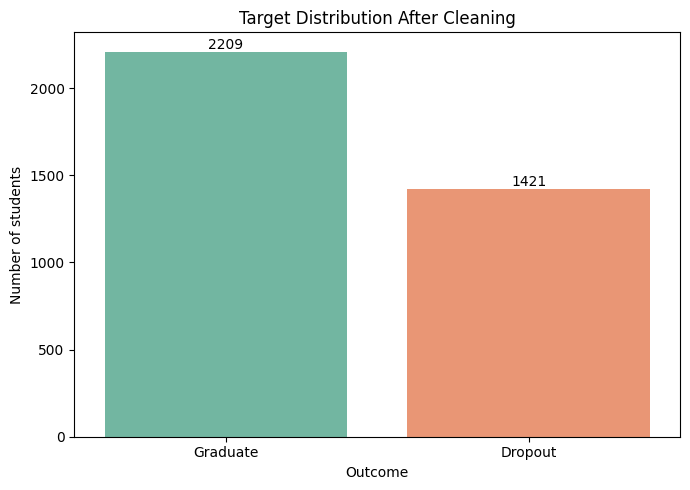

In [50]:
# Compact EDA: target balance after cleaning
target_labels = {0: 'Graduate', 1: 'Dropout'}
eda_df = df.reset_index(drop=True).copy()
eda_df['target_label'] = eda_df['target'].map(target_labels)

fig, ax = plt.subplots(figsize=(7, 5))
target_counts = eda_df['target_label'].value_counts().reindex(['Graduate', 'Dropout'])
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax, palette='Set2')
ax.set_title('Target Distribution After Cleaning')
ax.set_xlabel('Outcome')
ax.set_ylabel('Number of students')
for i, v in enumerate(target_counts.values):
    ax.text(i, v, f'{v}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


This chart gives a simple overview of the cleaned binary outcome after removing `Enrolled`. It confirms that dropout is common enough to model seriously, while still leaving enough graduates to make the prediction task non-trivial. This is useful context for the later choice to prioritise recall and false negative rate, since the model needs to identify a substantial at-risk group without overwhelming the intervention system.


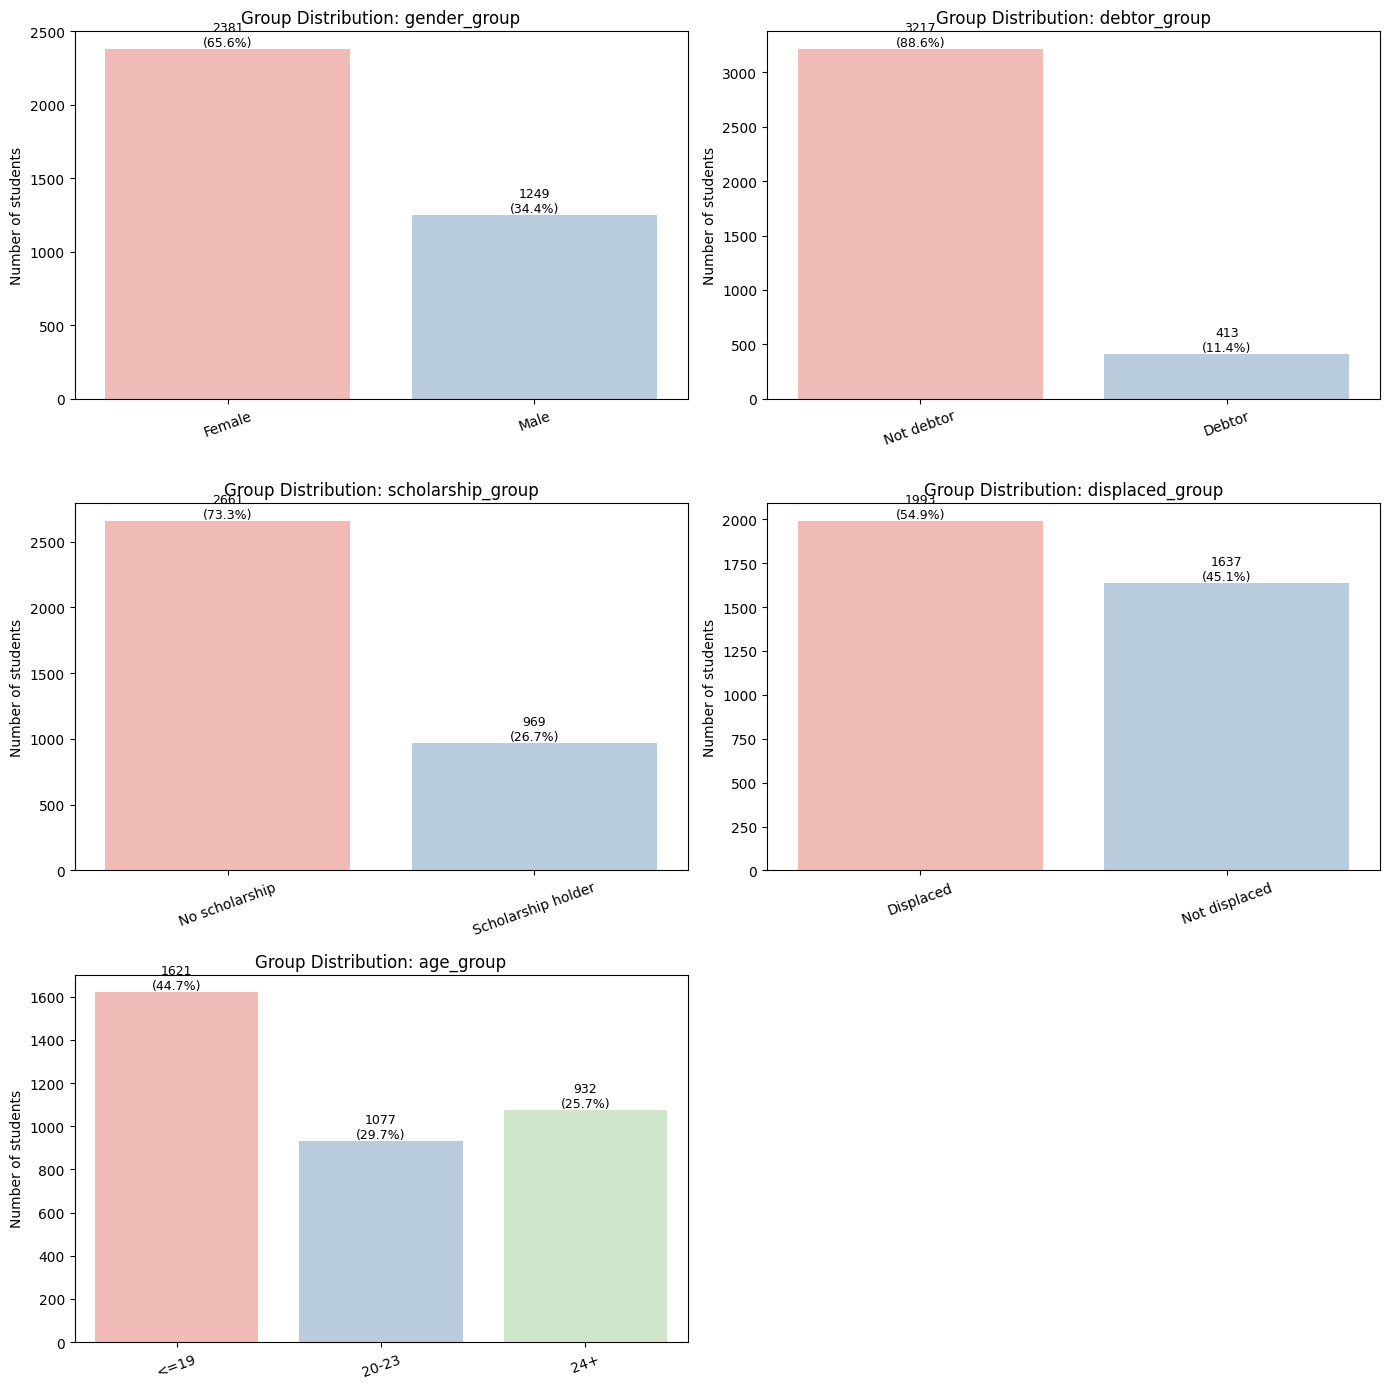

In [51]:
# Distribution of the selected sensitive groups in the cleaned dataset
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, attr in zip(axes, sensitive_attrs):
    count_df = eda_df[attr].value_counts(dropna=False).reset_index()
    count_df.columns = [attr, 'n']
    sns.barplot(data=count_df, x=attr, y='n', ax=ax, palette='Pastel1')
    ax.set_title(f'Group Distribution: {attr}')
    ax.set_xlabel('')
    ax.set_ylabel('Number of students')
    ax.tick_params(axis='x', rotation=20)
    total = count_df['n'].sum()
    for p, (_, row) in zip(ax.patches, count_df.iterrows()):
        pct = row['n'] / total
        ax.text(p.get_x() + p.get_width()/2, p.get_height(), f"{int(row['n'])}\n({pct:.1%})", ha='center', va='bottom', fontsize=9)

if len(axes) > len(sensitive_attrs):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


These charts show the **size of each sensitive group** in the cleaned dataset. This matters because later fairness metrics should never be interpreted without group size in mind: a very small group can show unstable rates, while a large group contributes much more heavily to the overall intervention burden. Showing group composition here makes the later dropout-rate and fairness-audit comparisons easier to read in context.


,gender_group,dropout_rate,n,attribute,debtor_group,scholarship_group,displaced_group,age_group
0,Female,0.302394,2381,gender_group,NaN,NaN,NaN,NaN
1,Male,0.561249,1249,gender_group,NaN,NaN,NaN,NaN
2,NaN,0.755448,413,debtor_group,Debtor,NaN,NaN,NaN
3,NaN,0.344731,3217,debtor_group,Not debtor,NaN,NaN,NaN
4,NaN,0.483653,2661,scholarship_group,NaN,No scholarship,NaN,NaN
5,NaN,0.138287,969,scholarship_group,NaN,Scholarship holder,NaN,NaN
6,NaN,0.335675,1993,displaced_group,NaN,NaN,Displaced,NaN
7,NaN,0.459377,1637,displaced_group,NaN,NaN,Not displaced,NaN
8,NaN,0.252313,1621,age_group,NaN,NaN,NaN,<=19
9,NaN,0.348712,932,age_group,NaN,NaN,NaN,20-23


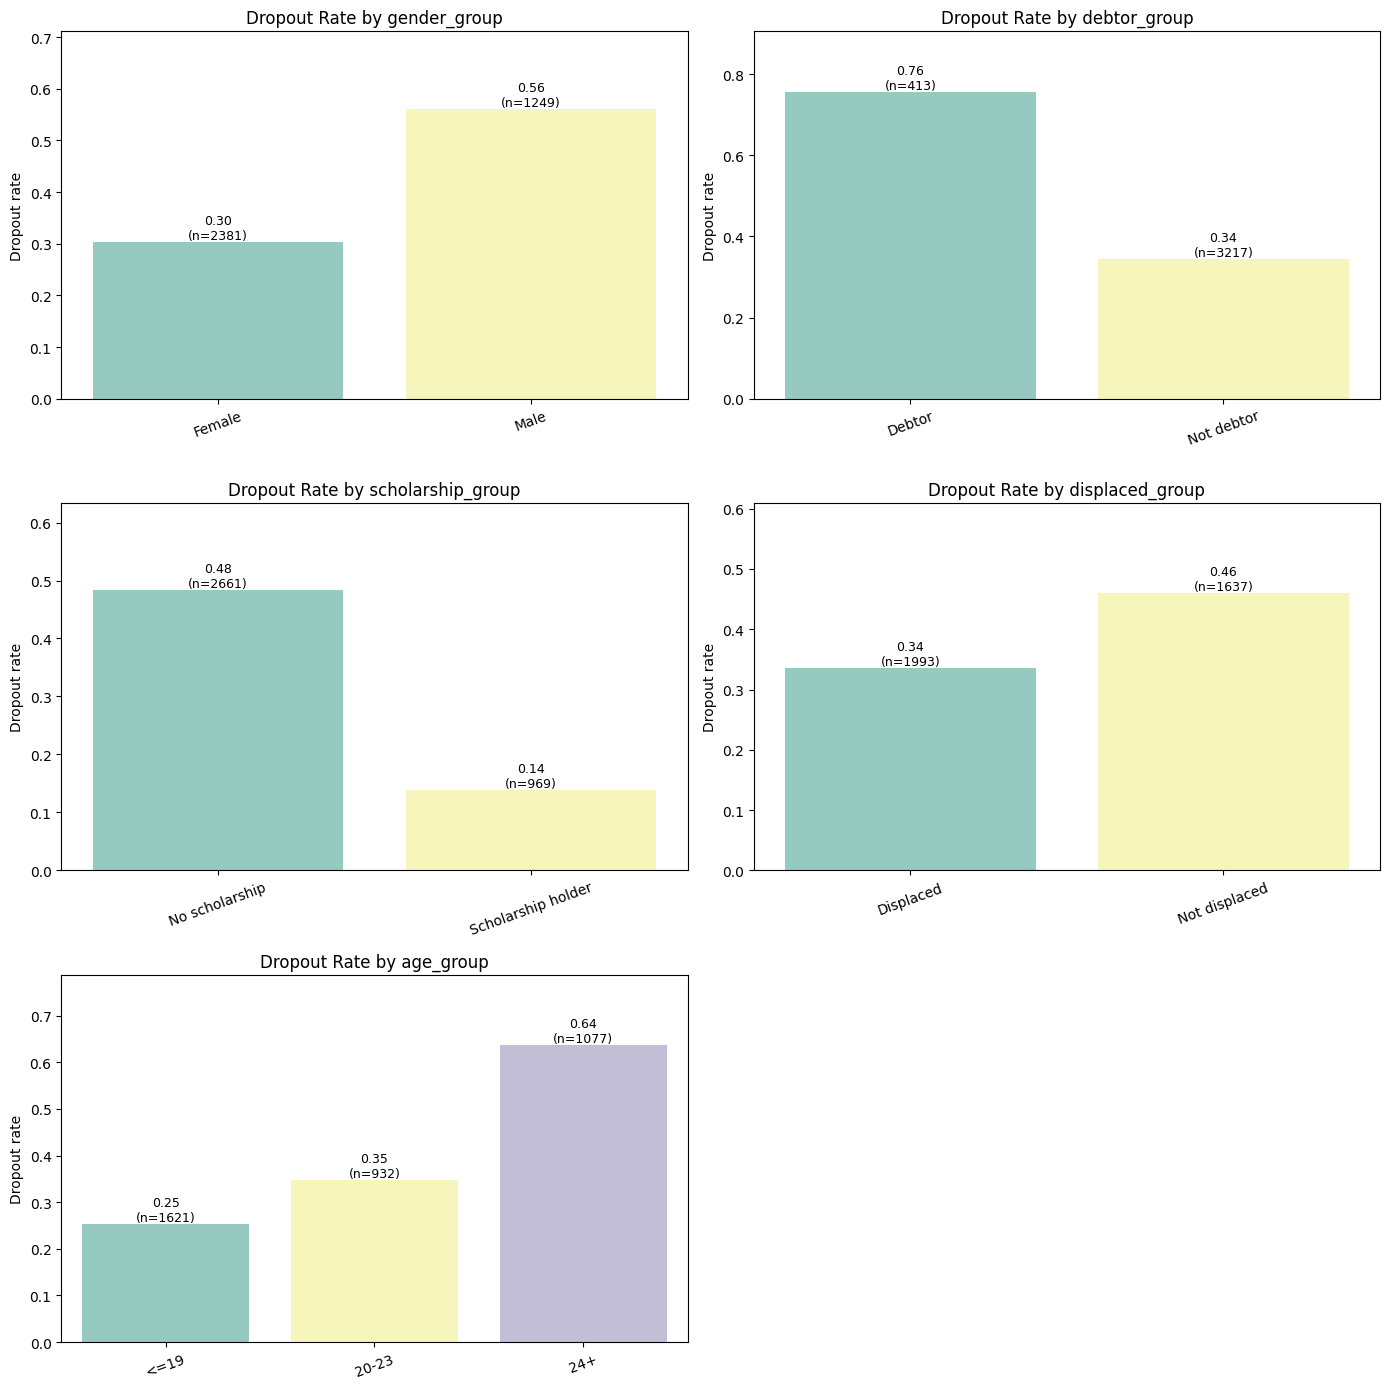

In [52]:
# Raw group-level dropout rates for the selected sensitive attributes
group_rate_frames = []
for attr in sensitive_attrs:
    temp = (
        eda_df.groupby(attr, observed=False)['target']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'dropout_rate', 'count': 'n'})
        .reset_index()
    )
    temp['attribute'] = attr
    group_rate_frames.append(temp)

group_dropout_rates = pd.concat(group_rate_frames, ignore_index=True)
display(group_dropout_rates)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, attr in zip(axes, sensitive_attrs):
    plot_df = group_dropout_rates[group_dropout_rates['attribute'] == attr].copy()
    sns.barplot(data=plot_df, x=attr, y='dropout_rate', ax=ax, palette='Set3')
    ax.set_title(f'Dropout Rate by {attr}')
    ax.set_xlabel('')
    ax.set_ylabel('Dropout rate')
    ax.set_ylim(0, min(1.0, plot_df['dropout_rate'].max() + 0.15))
    ax.tick_params(axis='x', rotation=20)
    for p, (_, row) in zip(ax.patches, plot_df.iterrows()):
        ax.text(p.get_x() + p.get_width()/2, p.get_height(), f"{row['dropout_rate']:.2f}\n(n={int(row['n'])})", ha='center', va='bottom', fontsize=9)

if len(axes) > len(sensitive_attrs):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


These charts compare the **raw dropout rates** of each selected sensitive group before any model is trained. This is one of the most important descriptive checks in the notebook, because it shows whether the groups differ in observed dropout exposure even before we ask whether the model treats them differently. The later fairness audit is still necessary, since unequal base rates do not automatically justify unequal false negative rates, but these plots give the right baseline context for interpreting those fairness results.


### Split Train and Test

We use stratification because it keeps the dropout rate nearly the same in both sets, which makes the evaluation more reliable.




In [53]:
X = df[[c for c in df.columns if c not in ['target', 'Target', *sensitive_attrs]]]
Y = df['target']
A = df[sensitive_attrs]

np.random.seed(random_seed)

X_train, X_test, Y_train, Y_test, A_train, A_test, df_train, df_test = train_test_split(
    X, Y, A, df,
    test_size=0.30,
    stratify=Y,
    random_state=random_seed
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"\nTrain target distribution:\n{Y_train.value_counts(normalize=True).round(3).to_string()}")
print(f"\nTest target distribution:\n{Y_test.value_counts(normalize=True).round(3).to_string()}")


Train size: 2541 | Test size: 1089

Train target distribution:
target
0    0.608
1    0.392

Test target distribution:
target
0    0.609
1    0.391


 Both sets keep almost exactly the same class balance, with about `61%` graduates and `39%` dropouts. That tells us the stratified split worked correctly, so later model comparisons are not being distorted by an uneven test set.


# Model Training: Logistic Regression

We start with Logistic Regression as the **interpretable baseline**.

Two additional details are important here:
1. We first remove multicollinear variables using a **VIF > 5** rule
2. We then inspect p-values and retain only statistically significant features for the final baseline model



In [ ]:
# VIF filtering step
# The goal is to keep a stable feature set for Logistic Regression and avoid
# inflated standard errors caused by strong multicollinearity.
# To stay faithful to the mitigation logic, we do NOT allow
# the key fairness-related predictors to be dropped automatically.
protected_vif_features = ['Age at enrollment', 'Gender', 'Debtor', 'Scholarship holder', 'Displaced']
vif_features, removed_vif_df, final_vif_df = iterative_vif_filter(
    X_train.astype(float),
    threshold=5.0,
    protected_cols=protected_vif_features,
)

print(f"Selected {len(vif_features)} VIF-approved features (VIF <= 5 for non-protected variables):")
print(vif_features)
print(f"\nProtected from automatic VIF removal: {protected_vif_features}")

print("\nRemoved because VIF > 5:")
display(removed_vif_df)

print("\nFinal VIF table:")
display(final_vif_df)


Selected 18 VIF-approved features (VIF <= 5 for non-protected variables):
['Application mode', 'Application order', 'Previous qualification', "Mother's qualification", "Father's qualification", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Inflation rate', 'GDP']

Protected from automatic VIF removal: ['Age at enrollment', 'Gender', 'Debtor', 'Scholarship holder', 'Displaced']

Removed because VIF > 5:


,feature,vif
0,Curricular units 1st sem (enrolled),37.433603
1,Curricular units 1st sem (approved),19.764613
2,Unemployment rate,19.117631
3,Mother's occupation,10.201871
4,Curricular units 1st sem (evaluations),9.789141
5,Nacionality,9.279493
6,Tuition fees up to date,8.994691
7,Daytime/evening attendance,7.324784
8,Marital status,7.279769
9,Course,6.172156



Final VIF table:


,feature,vif
11,Age at enrollment,10.136978
14,Curricular units 1st sem (grade),4.843778
4,Father's qualification,4.796352
3,Mother's qualification,4.326502
5,Father's occupation,4.212674
0,Application mode,4.045966
1,Application order,3.003923
6,Displaced,2.505401
16,Inflation rate,1.825140
2,Previous qualification,1.777987


 The removed-variable table shows that several first-semester academic variables were highly collinear. After filtering, `18` features remain for the initial interpretable model, and the protected fairness-related predictors were kept in the candidate set on purpose.


This first statistical Logit model is fitted on the VIF-approved feature set. Its purpose is not final prediction performance but interpretation: it gives coefficients, odds ratios, and p-values so we can see which variables appear meaningfully related to dropout risk.



In [55]:
# Initial Logit model to analyse p-values for the VIF-approved features.
pre_log_reg = sm.Logit(Y_train, sm.add_constant(X_train[vif_features])).fit(disp=False)
print(pre_log_reg.summary())


                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 2541
Model:                          Logit   Df Residuals:                     2522
Method:                           MLE   Df Model:                           18
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.3441
Time:                        15:21:37   Log-Likelihood:                -1115.8
converged:                       True   LL-Null:                       -1701.1
Covariance Type:            nonrobust   LLR p-value:                2.291e-237
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                                              1.0090      0.308      3.274      0.001       0.405       1.613
Application mode       

In [56]:
# Coefficient table sorted by p-value — inspect sensitive attribute coefficients.
coefs = pd.DataFrame({
    'coef': pre_log_reg.params.values,
    'odds_ratio': np.exp(pre_log_reg.params.values),
    'pvalue': round(pre_log_reg.pvalues, 4),
    'feature': pre_log_reg.params.index
}).sort_values('pvalue')
display(coefs)

sensitive_feature_columns = ['Gender', 'Debtor', 'Scholarship holder', 'Displaced', 'Age at enrollment']
print("Sensitive feature coefficients:")
display(coefs[coefs['feature'].isin(sensitive_feature_columns)])


,coef,odds_ratio,pvalue,feature
Debtor,2.109680,8.245599,0.0000,Debtor
Application mode,0.058387,1.060125,0.0000,Application mode
Curricular units 1st sem (grade),-0.246923,0.781201,0.0000,Curricular units 1st sem (grade)
Scholarship holder,-1.235029,0.290826,0.0000,Scholarship holder
Gender,0.664198,1.942931,0.0000,Gender
Age at enrollment,0.030685,1.031161,0.0002,Age at enrollment
Curricular units 1st sem (credited),-0.074562,0.928150,0.0004,Curricular units 1st sem (credited)
const,1.008967,2.742766,0.0011,const
Father's occupation,-0.035561,0.965064,0.0058,Father's occupation
Curricular units 1st sem (without evaluations),0.104450,1.110100,0.1698,Curricular units 1st sem (without evaluations)


Sensitive feature coefficients:


,coef,odds_ratio,pvalue,feature
Debtor,2.109680,8.245599,0.0000,Debtor
Scholarship holder,-1.235029,0.290826,0.0000,Scholarship holder
Gender,0.664198,1.942931,0.0000,Gender
Age at enrollment,0.030685,1.031161,0.0002,Age at enrollment
Displaced,0.103024,1.108518,0.3951,Displaced


The table shows that Debtor, Scholarship holder, Gender, and Age at enrollment are statistically significant predictors in the initial Logistic Regression model. Debtor is associated with much higher dropout risk, while Scholarship holder is associated with lower dropout risk. Gender and Age at enrollment are also significant, with older students showing slightly higher predicted dropout risk. Displaced is not statistically significant in this model, so it is more useful as a fairness-audit variable than as a strong independent predictor.


## Coefficient Analysis & Fairness Implications for Sensitive Attributes
- The sign of a coefficient tells us the direction of the association: positive values raise predicted dropout risk, while negative values lower it.
- The odds ratio tells us the size of that association in a more interpretable way.
- In this table, debtor status stands out as the strongest risk marker, while scholarship status appears protective.


We keep only the features that are statistically significant at `p < 0.05` and refit the Logistic Regression model on that reduced feature set. The goal is to build a simpler and more explainable baseline without carrying unnecessary variables into the final LR model.



In [57]:
# Retrain with features significant at p < 0.05
log_reg_var = list(X_train[vif_features].columns[pre_log_reg.pvalues.drop('const') < 0.05])
print(f"Selected {len(log_reg_var)} features with p < 0.05:")
print(log_reg_var)

log_reg_sm = sm.Logit(Y_train, sm.add_constant(X_train[log_reg_var])).fit(disp=False)
print(log_reg_sm.summary())


Selected 8 features with p < 0.05:
['Application mode', "Father's occupation", 'Debtor', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (grade)']
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 2541
Model:                          Logit   Df Residuals:                     2532
Method:                           MLE   Df Model:                            8
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.3411
Time:                        15:21:37   Log-Likelihood:                -1120.9
converged:                       True   LL-Null:                       -1701.1
Covariance Type:            nonrobust   LLR p-value:                3.463e-245
                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

The model keeps only `8` statistically significant features. 

In [58]:
# Final coefficient table for the selected model
coefs_final = pd.DataFrame({
    'coef': log_reg_sm.params.values,
    'odds_ratio': np.exp(log_reg_sm.params.values),
    'pvalue': log_reg_sm.pvalues,
    'feature': log_reg_sm.params.index
}).sort_values('odds_ratio', ascending=False)
display(coefs_final)


,coef,odds_ratio,pvalue,feature
Debtor,2.065524,7.889428,8.318473e-31,Debtor
const,1.190043,3.287222,2.236952e-06,const
Gender,0.633953,1.885048,1.091157e-08,Gender
Application mode,0.052063,1.053442,4.555860e-06,Application mode
Age at enrollment,0.033536,1.034105,3.940883e-06,Age at enrollment
Father's occupation,-0.033010,0.967528,7.907254e-03,Father's occupation
Curricular units 1st sem (credited),-0.069127,0.933208,7.189055e-04,Curricular units 1st sem (credited)
Curricular units 1st sem (grade),-0.248223,0.780186,1.989714e-71,Curricular units 1st sem (grade)
Scholarship holder,-1.225856,0.293506,1.089203e-17,Scholarship holder


In the final Logistic Regression model, the strongest risk-increasing variables are `Debtor`, `Gender`, `Application mode`, and `Age at enrollment`, while higher first-semester grades and scholarship status are associated with lower dropout risk. 


### Pipeline with LogisticRegression

In [59]:
# Build sklearn Pipeline with StandardScaler + LogisticRegression
# class_weight='balanced' adjusts for the class imbalance
clf_log = LogisticRegression(random_state=random_seed, class_weight='balanced', max_iter=3000)

unmitigated_pipeline = Pipeline(steps=[
    ("selector", ColumnTransformer([
        ("selector", "passthrough", log_reg_var)
    ], remainder="drop")),
    ("scaler", StandardScaler()),
    ("logistic_regression", clf_log)
])

LOG = unmitigated_pipeline.fit(X_train, Y_train)
LOG


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('selector', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('selector', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [60]:
# Evaluate on test set
Y_pred_log = LOG.predict(X_test)

print('--- Classification Report ---')
print(classification_report(Y_test, Y_pred_log, target_names=['Graduate', 'Dropout']))

print('--- 10-Fold Cross-Validation (F1 weighted) ---')
cv_scores = cross_val_score(LOG, X_train, Y_train.values.ravel(), cv=10, scoring='f1_weighted')
print(f"CV scores: {cv_scores.round(3)}")
print(f"Mean CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


--- Classification Report ---
              precision    recall  f1-score   support

    Graduate       0.83      0.84      0.83       663
     Dropout       0.74      0.73      0.74       426

    accuracy                           0.80      1089
   macro avg       0.79      0.78      0.78      1089
weighted avg       0.79      0.80      0.79      1089

--- 10-Fold Cross-Validation (F1 weighted) ---
CV scores: [0.827 0.794 0.815 0.773 0.778 0.79  0.812 0.775 0.822 0.791]
Mean CV F1: 0.798 ± 0.019


The Logistic Regression baseline shows reasonable overall performance, with 80% accuracy and a weighted cross-validation F1 of about 0.80, indicating that the model is fairly stable across folds. However, for the Dropout class, recall is only 0.73, meaning that about 27% of true dropouts are missed. This is a key limitation in our setting, since false negatives are especially costly when the goal is to identify students in need of early intervention.


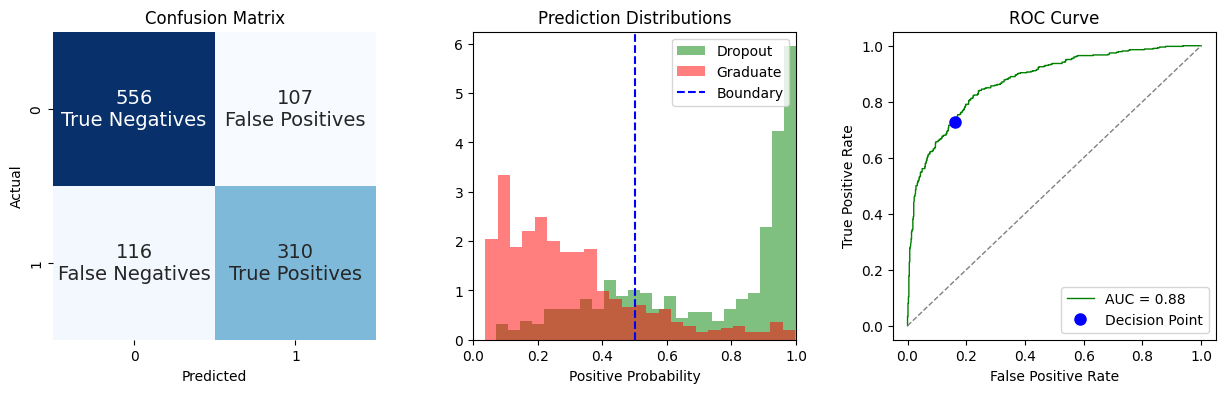

Precision: 0.74 | Recall: 0.73 | F1: 0.74


np.float64(0.7354685646500594)

In [ ]:
eval_binary_classifier(LOG, X_test, Y_test)

The diagnostic plots show that the Logistic Regression model has meaningful predictive power, but still makes important mistakes for the intervention setting. The confusion matrix indicates that 116 true dropouts are misclassified as non-dropouts, which is problematic because these students would not receive support. The probability distributions show partial separation between graduates and dropouts, but also substantial overlap, explaining why errors remain. The ROC curve, with an AUC of about 0.88, confirms that the model has good overall ranking ability, suggesting that the main issue is not lack of signal but the trade-off created by the chosen decision threshold.

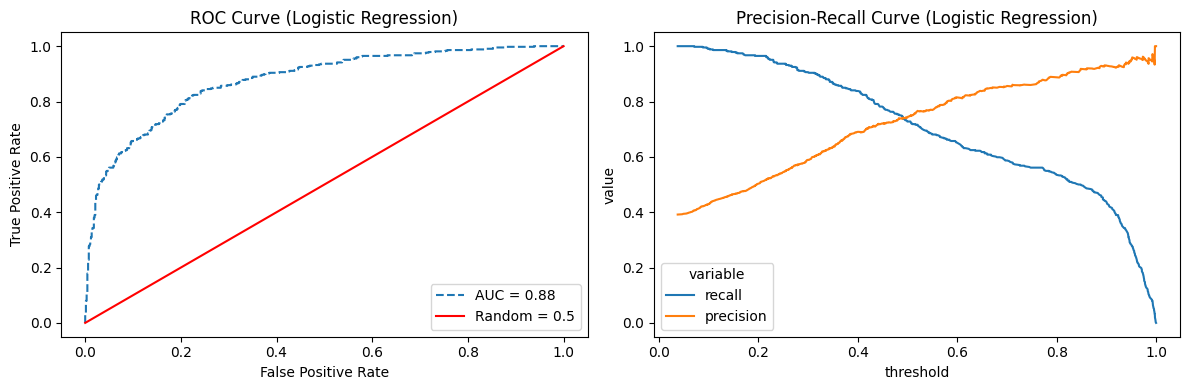

In [ ]:
plot_roc_pr(X_test, Y_test, LOG, title="(Logistic Regression)")

# Model Training: XGBoost

We train XGBoost as the more **expressive alternative** to Logistic Regression.




XGBoost is included because we compare an interpretable baseline with a stronger nonlinear model. The point is to see whether better predictive performance also changes the fairness picture. The conservative hyperparameters, subsampling, and early stopping are there to limit overfitting and keep the comparison defensible.

For clean evaluation, early stopping is now done on a validation split created from the training data, while the test set is kept untouched until final evaluation.


Best iteration (early stopping): 173


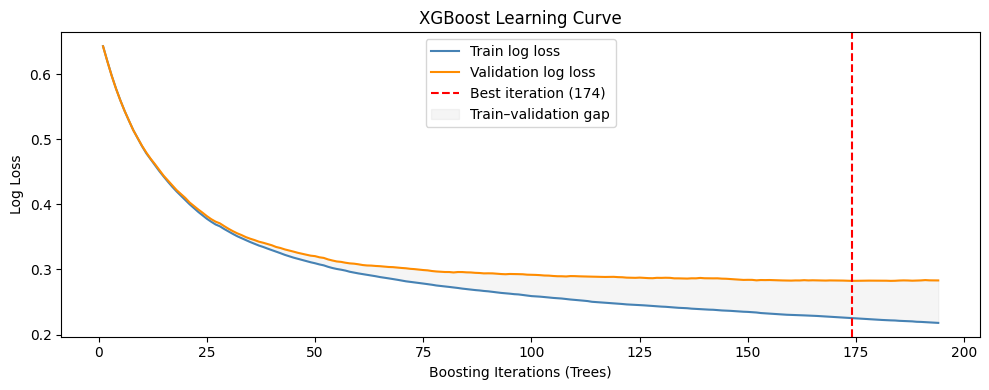

In [63]:
X_train_xgb, X_val_xgb, Y_train_xgb, Y_val_xgb = train_test_split(
    X_train, Y_train,
    test_size=0.20,
    stratify=Y_train,
    random_state=random_seed
)

clf_xgb = XGBClassifier(
    max_depth=4,             # shallower trees reduce memorisation
    learning_rate=0.05,
    n_estimators=500,        # early stopping will find the optimal count
    objective='binary:logistic',
    booster='gbtree',
    eval_metric='logloss',
    early_stopping_rounds=20,
    subsample=0.8,           # each tree sees 80% of rows → reduces variance
    colsample_bytree=0.8,    # each tree sees 80% of features → reduces variance
    min_child_weight=5,      # >=5 samples per leaf → prevents splits on noise
    reg_lambda=2,            # mild L2 regularisation
    random_state=42,
    n_jobs=1
)

unmitigated_pipeline_xgb = Pipeline(steps=[("xgb", clf_xgb)])

eval_set = [(X_train_xgb, Y_train_xgb), (X_val_xgb, Y_val_xgb)]
XGB = unmitigated_pipeline_xgb.fit(
    X_train_xgb, Y_train_xgb,
    xgb__eval_set=eval_set,
    xgb__verbose=False
)

best_iter = XGB.steps[0][1].best_iteration
print(f"Best iteration (early stopping): {best_iter}")

# Learning curve
results = XGB.steps[0][1].evals_result()
train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']
iters = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(iters, train_loss, label='Train log loss', color='steelblue')
ax.plot(iters, val_loss,   label='Validation log loss', color='darkorange')
ax.axvline(best_iter + 1, color='red', linestyle='--', label=f'Best iteration ({best_iter + 1})')
ax.fill_between(iters, train_loss, val_loss, alpha=0.08, color='grey', label='Train–validation gap')
ax.set_xlabel('Boosting Iterations (Trees)')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost Learning Curve')
ax.legend()
plt.tight_layout()
plt.show()


--- Classification Report ---
              precision    recall  f1-score   support

    Graduate       0.90      0.94      0.92       663
     Dropout       0.90      0.84      0.87       426

    accuracy                           0.90      1089
   macro avg       0.90      0.89      0.89      1089
weighted avg       0.90      0.90      0.90      1089



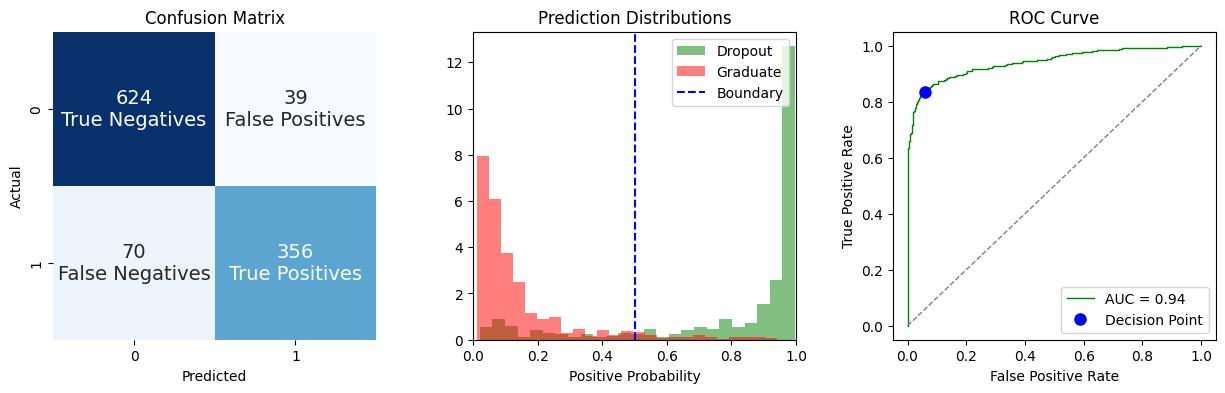

Precision: 0.90 | Recall: 0.84 | F1: 0.87


np.float64(0.8672350791717417)

In [ ]:
Y_pred_xgb = XGB.predict(X_test)
print('--- Classification Report ---')
print(classification_report(Y_test, Y_pred_xgb, target_names=['Graduate', 'Dropout']))
eval_binary_classifier(XGB, X_test, Y_test)

The XGBoost model performs substantially better than the Logistic Regression baseline. For the Dropout class, it achieves 0.90 precision, 0.84 recall, and an F1 score of 0.87, indicating a strong balance between correctly identifying at-risk students and avoiding unnecessary false alarms. The confusion matrix shows that only 70 true dropouts are missed, which is a clear improvement over Logistic Regression and is especially important in our intervention setting, where false negatives are costly. The probability distributions are more clearly separated, and the ROC curve shows excellent discrimination with an AUC of about 0.94, supporting the conclusion that XGBoost is the stronger predictive model.

**What this code does:** This cell plots the ROC and precision-recall curves for XGBoost. These curves help confirm visually whether the stronger model is genuinely separating risky and non-risky students better than the baseline.


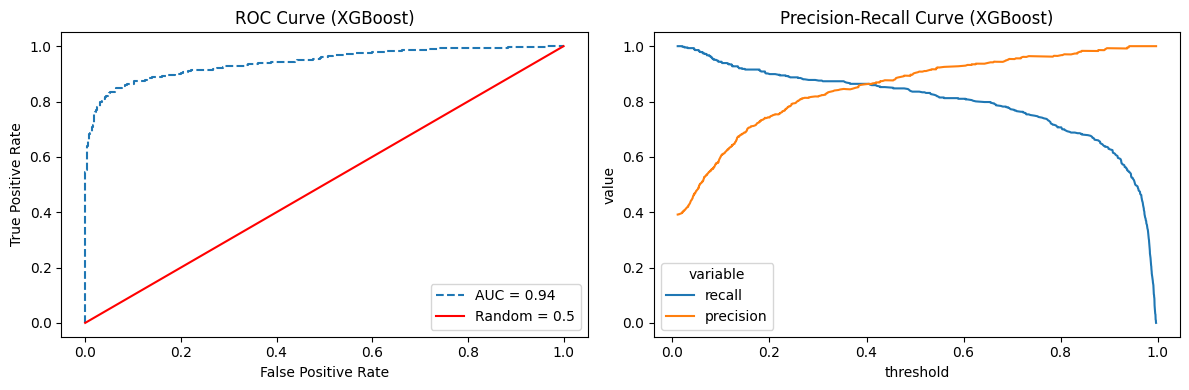

In [ ]:
plot_roc_pr(X_test, Y_test, XGB, title="(XGBoost)")

## LR vs. XGBoost: Performance Summary

This table compares the two baseline models at the **default threshold**.


- `Recall` matters most, because false negatives are the main harm
- `Precision` still matters because interventions are resource-limited
- `F1` summarises the precision-recall balance
- `ROC-AUC` is useful as a ranking-quality measure but is not the final operational objective


In [ ]:
performance_df = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'recall': recall_score(Y_test, Y_pred_log),
        'precision': precision_score(Y_test, Y_pred_log),
        'f1': f1_score(Y_test, Y_pred_log),
        'roc_auc': roc_auc_score(Y_test, LOG.predict_proba(X_test)[:, 1]),
    },
    {
        'model': 'XGBoost',
        'recall': recall_score(Y_test, Y_pred_xgb),
        'precision': precision_score(Y_test, Y_pred_xgb),
        'f1': f1_score(Y_test, Y_pred_xgb),
        'roc_auc': roc_auc_score(Y_test, XGB.predict_proba(X_test)[:, 1]),
    }
]).sort_values(['recall', 'f1', 'roc_auc'], ascending=False).reset_index(drop=True)

display(performance_df)

,model,recall,precision,f1,roc_auc
0,XGBoost,0.835681,0.901266,0.867235,0.941775
1,Logistic Regression,0.727700,0.743405,0.735469,0.875137


The performance summary shows that XGBoost clearly outperforms Logistic Regression on all key metrics. XGBoost achieves higher recall (0.836 vs. 0.728), much higher precision (0.901 vs. 0.743), a stronger F1 score (0.867 vs. 0.735), and better overall discrimination with a ROC-AUC of 0.942 compared with 0.875. This indicates that XGBoost is substantially more effective at identifying students at risk of dropout, while also producing fewer false alarms than the Logistic Regression baseline.

# Operational Threshold Selection

We evaluate thresholds using `F2`, which weights recall more heavily than precision.



A default threshold of `0.50` is rarely optimal when false negatives are the main concern. `F2` is chosen instead of F1 because it weights recall more heavily, which better matches the intervention objective.


In [67]:
prob_log = LOG.predict_proba(X_test)[:, 1]
prob_xgb = XGB.predict_proba(X_test)[:, 1]

threshold_results_log = threshold_table(Y_test, prob_log)
threshold_results_xgb = threshold_table(Y_test, prob_xgb)

display(threshold_results_log.head(10))
display(threshold_results_xgb.head(10))

best_threshold_log = threshold_results_log.loc[0, 'threshold']
best_threshold_xgb = threshold_results_xgb.loc[0, 'threshold']

Y_pred_log_operational = (prob_log >= best_threshold_log).astype(int)
Y_pred_xgb_operational = (prob_xgb >= best_threshold_xgb).astype(int)

threshold_summary_df = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'best_threshold': best_threshold_log,
        'best_recall': threshold_results_log.loc[0, 'recall'],
        'best_precision': threshold_results_log.loc[0, 'precision'],
        'best_f1': threshold_results_log.loc[0, 'f1'],
        'best_f2': threshold_results_log.loc[0, 'f2'],
    },
    {
        'model': 'XGBoost',
        'best_threshold': best_threshold_xgb,
        'best_recall': threshold_results_xgb.loc[0, 'recall'],
        'best_precision': threshold_results_xgb.loc[0, 'precision'],
        'best_f1': threshold_results_xgb.loc[0, 'f1'],
        'best_f2': threshold_results_xgb.loc[0, 'f2'],
    }
]).sort_values(['best_f2', 'best_recall'], ascending=False).reset_index(drop=True)

display(threshold_summary_df)


,threshold,accuracy,precision,recall,f1,f2,fnr,tnr
0,0.25,0.669421,0.545082,0.936620,0.689119,0.818966,0.063380,0.497738
1,0.30,0.716253,0.589313,0.906103,0.714154,0.818143,0.093897,0.594268
2,0.20,0.613407,0.503060,0.964789,0.661303,0.815153,0.035211,0.387632
3,0.35,0.752066,0.634021,0.866197,0.732143,0.807087,0.133803,0.678733
4,0.40,0.788797,0.689189,0.838028,0.756356,0.803330,0.161972,0.757164
5,0.15,0.550964,0.464883,0.978873,0.630385,0.801615,0.021127,0.276018
6,0.10,0.480257,0.428862,0.990610,0.598582,0.784970,0.009390,0.152338
7,0.45,0.796143,0.720779,0.781690,0.750000,0.768698,0.218310,0.805430
8,0.50,0.795225,0.743405,0.727700,0.735469,0.730787,0.272300,0.838612
9,0.55,0.795225,0.769231,0.680751,0.722291,0.696780,0.319249,0.868778


,threshold,accuracy,precision,recall,f1,f2,fnr,tnr
0,0.35,0.887052,0.843537,0.873239,0.858131,0.867133,0.126761,0.895928
1,0.25,0.865014,0.792453,0.887324,0.837209,0.866575,0.112676,0.850679
2,0.30,0.876033,0.818381,0.877934,0.847112,0.865340,0.122066,0.874811
3,0.20,0.839302,0.742747,0.901408,0.814422,0.864475,0.098592,0.799397
4,0.40,0.892562,0.861827,0.863850,0.862837,0.863444,0.136150,0.911011
5,0.15,0.804408,0.687831,0.915493,0.785498,0.858653,0.084507,0.733032
6,0.45,0.895317,0.876812,0.852113,0.864286,0.856941,0.147887,0.923077
7,0.50,0.899908,0.901266,0.835681,0.867235,0.848023,0.164319,0.941176
8,0.10,0.733701,0.601796,0.943662,0.734918,0.847386,0.056338,0.598793
9,0.55,0.900826,0.922872,0.814554,0.865337,0.834135,0.185446,0.956259


,model,best_threshold,best_recall,best_precision,best_f1,best_f2
0,XGBoost,0.35,0.873239,0.843537,0.858131,0.867133
1,Logistic Regression,0.25,0.936620,0.545082,0.689119,0.818966


The threshold analysis shows that both models improve when the decision cutoff is adjusted to prioritise recall, but XGBoost remains the stronger operational model. At its best threshold (0.35), XGBoost achieves high recall (0.873) while still maintaining strong precision (0.844) and the highest F2 score (0.867). Logistic Regression reaches even higher recall (0.937) at a lower threshold (0.25), but this comes with much lower precision (0.545), meaning many more students would be flagged unnecessarily. This suggests that XGBoost offers the better balance between identifying at-risk students and keeping interventions practically manageable.

# Bias Audit

1. Identify the harm
2. Identify the groups at risk
3. Measure disparities
4. Interpret whether mitigation is needed

- the harm is **missed support for a student who actually needs intervention**
- in classification terms, the harm is a **false negative**
- so the most important fairness metric is **False Negative Rate**
- because the university would deploy the model with the **F2-selected operational threshold**, the fairness audit should be performed at that threshold rather than only at the default `0.5` cutoff
- this makes the fairness results match the way the model would actually be used in practice


In [68]:
# Shared metric dictionary used throughout the audit and mitigation sections
metrics_dict = {
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "false_negative_rate": false_negative_rate,
    "balanced_accuracy": balanced_accuracy_score,
    "f1_score": f1_score,
    "f2_score": lambda y_true, y_pred: fbeta_score(y_true, y_pred, beta=2, zero_division=0)
}


### Logistic Regression audit by all selected sensitive attributes on operational threshold 


In [69]:
mf_lr = {}

for attr in sensitive_attrs:
    mf_lr[attr] = MetricFrame(
        metrics=metrics_dict,
        y_true=Y_test,
        y_pred=Y_pred_log_operational,
        sensitive_features=A_test[attr]
    )

    print(f"Disaggregated metrics (LR | {attr}):")
    display(mf_lr[attr].by_group)
    display(pd.DataFrame({
        'difference': mf_lr[attr].difference(),
        'ratio': mf_lr[attr].ratio(),
        'group_min': mf_lr[attr].group_min(),
        'group_max': mf_lr[attr].group_max()
    }).T)


Disaggregated metrics (LR | gender_group):


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
gender_group,,,,,,
Female,0.537464,0.390144,0.115942,0.746957,0.631034,0.761865
Male,0.908861,0.812500,0.013699,0.586901,0.747405,0.874494


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.371397,0.422356,0.102243,0.160056,0.116370,0.112629
ratio,0.591360,0.480177,0.118151,0.785722,0.844301,0.871207
group_min,0.537464,0.390144,0.013699,0.586901,0.631034,0.761865
group_max,0.908861,0.812500,0.115942,0.746957,0.747405,0.874494


Disaggregated metrics (LR | debtor_group):


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
debtor_group,,,,,,
Debtor,0.978873,0.921053,0.000000,0.539474,0.855967,0.936937
Not debtor,0.626188,0.476800,0.083851,0.719675,0.644809,0.784157


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.352685,0.444253,0.083851,0.180201,0.211158,0.152780
ratio,0.639703,0.517669,0.000000,0.749608,0.753310,0.836937
group_min,0.626188,0.476800,0.000000,0.539474,0.644809,0.784157
group_max,0.978873,0.921053,0.083851,0.719675,0.855967,0.936937


Disaggregated metrics (LR | scholarship_group):


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
scholarship_group,,,,,,
No scholarship,0.837093,0.714988,0.035806,0.624603,0.711992,0.844534
Scholarship holder,0.219931,0.164062,0.371429,0.732254,0.444444,0.539216


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.617161,0.550925,0.335623,0.107651,0.267548,0.305318
ratio,0.262732,0.229462,0.096400,0.852987,0.624226,0.638477
group_min,0.219931,0.164062,0.035806,0.624603,0.444444,0.539216
group_max,0.837093,0.714988,0.371429,0.732254,0.711992,0.844534


Disaggregated metrics (LR | displaced_group):


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
displaced_group,,,,,,
Displaced,0.612350,0.489950,0.124324,0.692863,0.597786,0.738377
Not displaced,0.741107,0.520755,0.016598,0.731324,0.769481,0.884989


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.128757,0.030805,0.107727,0.038461,0.171695,0.146611
ratio,0.826264,0.940846,0.133502,0.947409,0.776870,0.834335
group_min,0.612350,0.489950,0.016598,0.692863,0.597786,0.738377
group_max,0.741107,0.520755,0.124324,0.731324,0.769481,0.884989


Disaggregated metrics (LR | age_group):


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
age_group,,,,,,
20-23,0.677193,0.547368,0.063158,0.694737,0.618056,0.776614
24+,0.938272,0.858491,0.022936,0.559287,0.816092,0.905612
<=19,0.489583,0.376022,0.141593,0.741193,0.557471,0.705968


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.448688,0.482469,0.118657,0.181906,0.258621,0.199644
ratio,0.521793,0.438003,0.161984,0.754577,0.683099,0.779548
group_min,0.489583,0.376022,0.022936,0.559287,0.557471,0.705968
group_max,0.938272,0.858491,0.141593,0.741193,0.816092,0.905612


The operational-threshold fairness audit shows that the Logistic Regression model still produces uneven outcomes across groups when evaluated at the F2-selected cutoff. Since the main concern is underflagging, the most important result is the false negative rate, and the largest remaining gaps appear for scholarship status (0.336), age group (0.119), displaced status (0.108), gender (0.102), and debtor status (0.084). In particular, the model misses more true dropouts among scholarship holders, female students, displaced students, non-debtors, and the youngest age group compared with their counterparts. Including F2 in the table is helpful because it shows that these disparities are being assessed under the same recall-focused threshold that would actually be used in practice, making the audit more aligned with the real intervention setting.

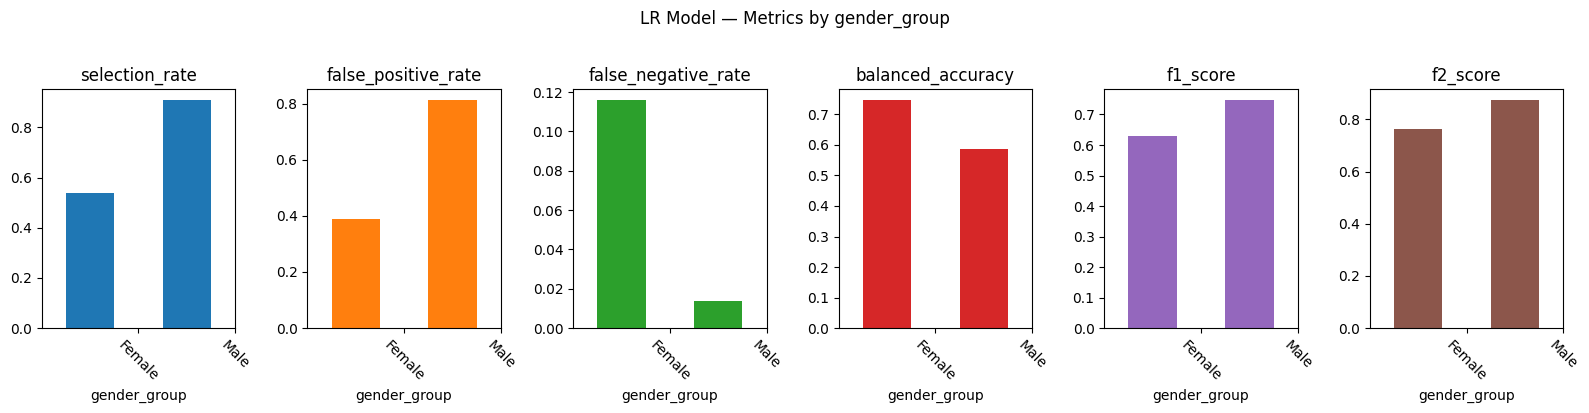

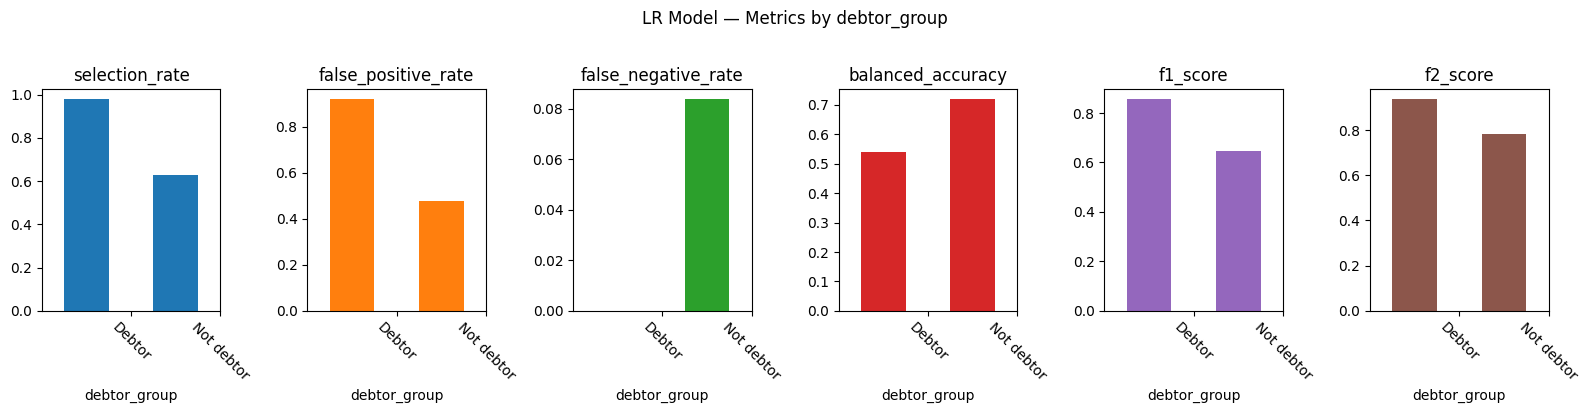

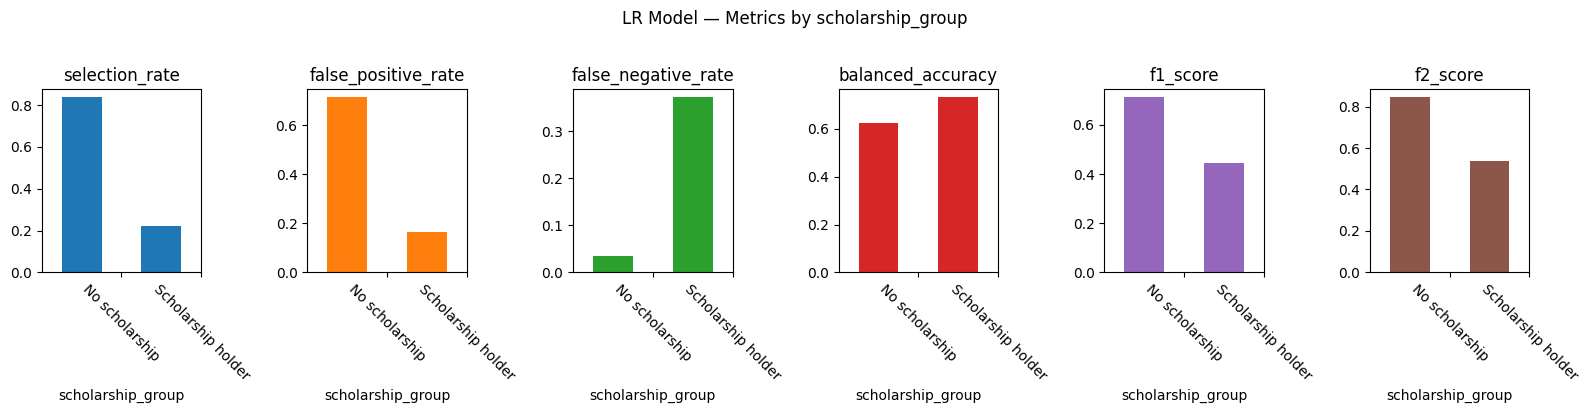

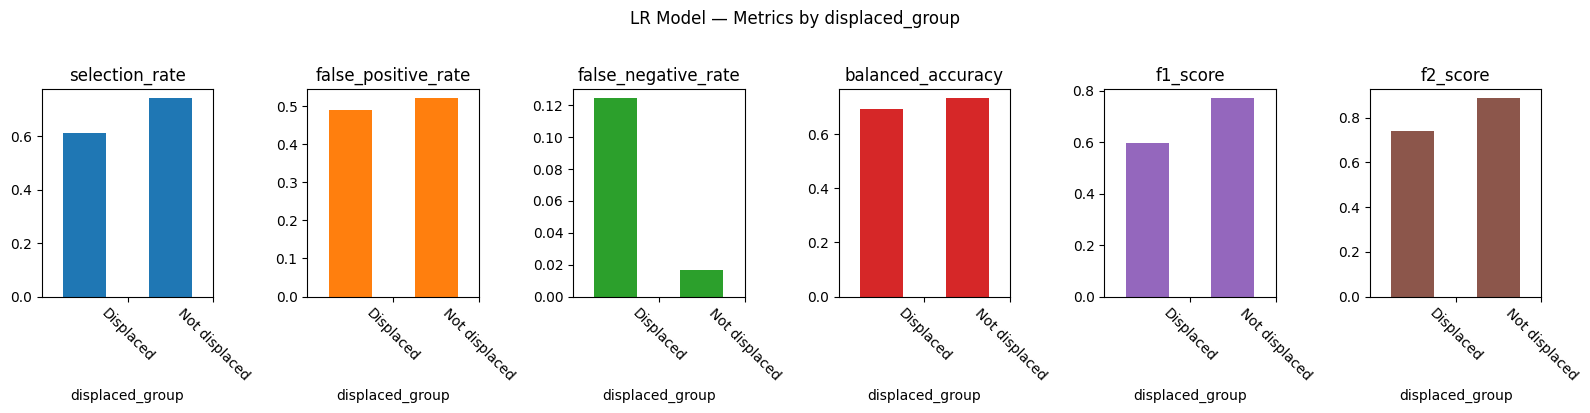

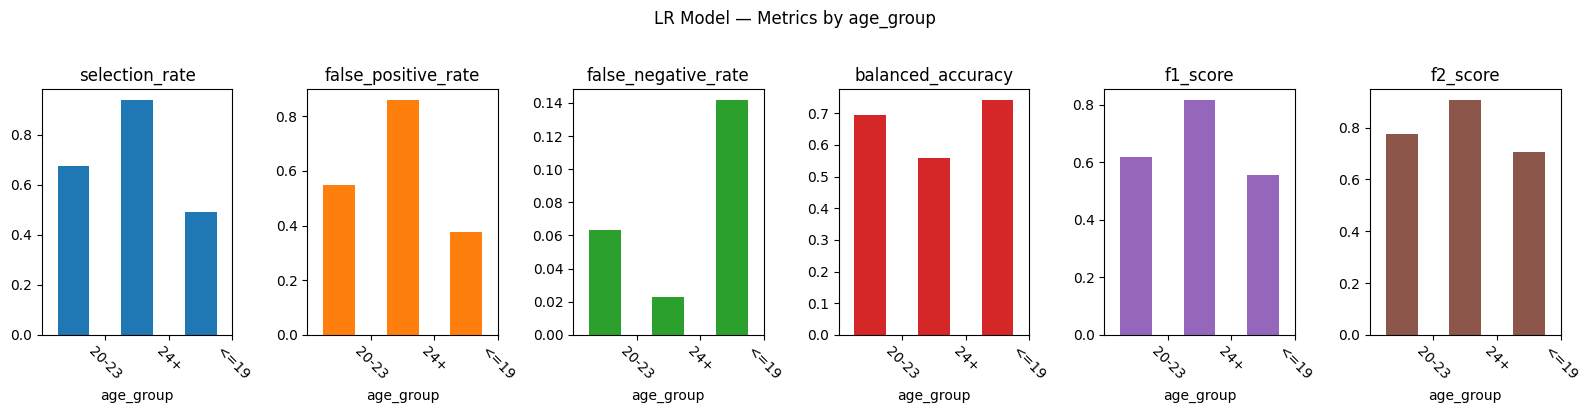

In [70]:
for attr in sensitive_attrs:
    mf_lr[attr].by_group.plot.bar(
        subplots=True, layout=[1, 6], figsize=(16, 4),
        legend=False, rot=-45, position=1.5
    )
    plt.suptitle(f"LR Model — Metrics by {attr}", y=1.02)
    plt.tight_layout()
    plt.show()


### XGBoost audit by all selected sensitive attributes on operational threshold 



In [71]:
mf_xgb = {}

for attr in sensitive_attrs:
    mf_xgb[attr] = MetricFrame(
        metrics=metrics_dict,
        y_true=Y_test,
        y_pred=Y_pred_xgb_operational,
        sensitive_features=A_test[attr]
    )

    print(f"XGBoost — by {attr}:")
    display(mf_xgb[attr].by_group)
    display(pd.DataFrame({
        'difference': mf_xgb[attr].difference(),
        'ratio': mf_xgb[attr].ratio(),
        'group_min': mf_xgb[attr].group_min(),
        'group_max': mf_xgb[attr].group_max()
    }).T)


XGBoost — by gender_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
gender_group,,,,,,
Female,0.306916,0.073922,0.144928,0.890575,0.842857,0.850144
Male,0.577215,0.187500,0.109589,0.851455,0.872483,0.883152


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.270299,0.113578,0.035338,0.039120,0.029626,0.033008
ratio,0.531719,0.394251,0.756164,0.956074,0.966044,0.962625
group_min,0.306916,0.073922,0.109589,0.851455,0.842857,0.850144
group_max,0.577215,0.187500,0.144928,0.890575,0.872483,0.883152


XGBoost — by debtor_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
debtor_group,,,,,,
Debtor,0.809859,0.315789,0.009615,0.837298,0.940639,0.969868
Not debtor,0.344245,0.091200,0.164596,0.872102,0.830247,0.833333


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.465614,0.224589,0.154981,0.034804,0.110392,0.136535
ratio,0.425068,0.288800,0.058418,0.960091,0.882641,0.859223
group_min,0.344245,0.091200,0.009615,0.837298,0.830247,0.833333
group_max,0.809859,0.315789,0.164596,0.872102,0.940639,0.969868


XGBoost — by scholarship_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
scholarship_group,,,,,,
No scholarship,0.510025,0.140049,0.104859,0.877546,0.877193,0.887874
Scholarship holder,0.116838,0.046875,0.371429,0.790848,0.637681,0.632184


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.393187,0.093174,0.266569,0.086698,0.239512,0.255690
ratio,0.229084,0.334704,0.282314,0.901205,0.726957,0.712020
group_min,0.116838,0.046875,0.104859,0.790848,0.637681,0.632184
group_max,0.510025,0.140049,0.371429,0.877546,0.877193,0.887874


XGBoost — by displaced_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
displaced_group,,,,,,
Displaced,0.337907,0.105528,0.162162,0.866155,0.811518,0.827108
Not displaced,0.482213,0.101887,0.099585,0.899264,0.894845,0.898179


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.144306,0.003641,0.062577,0.033109,0.083327,0.071071
ratio,0.700742,0.965499,0.614108,0.963182,0.906881,0.920872
group_min,0.337907,0.101887,0.099585,0.866155,0.811518,0.827108
group_max,0.482213,0.105528,0.162162,0.899264,0.894845,0.898179


XGBoost — by age_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
age_group,,,,,,
20-23,0.361404,0.110526,0.136842,0.876316,0.828283,0.848861
24+,0.669753,0.169811,0.087156,0.871516,0.914943,0.913682
<=19,0.252083,0.081744,0.194690,0.861783,0.777778,0.794066


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
difference,0.417670,0.088067,0.107534,0.014533,0.137165,0.119616
ratio,0.376382,0.481381,0.447665,0.983416,0.850084,0.869084
group_min,0.252083,0.081744,0.087156,0.861783,0.777778,0.794066
group_max,0.669753,0.169811,0.194690,0.876316,0.914943,0.913682


Compared with the operational-threshold Logistic Regression audit, XGBoost looks both stronger overall and somewhat fairer on most attributes, but not all. The false negative rate gap is much smaller for gender_group (0.035 vs. about 0.102 for LR), displaced_group (0.063 vs. 0.108), scholarship_group (0.267 vs. 0.336), and slightly smaller for age_group (0.108 vs. 0.119). However, debtor_group remains a concern, since the FNR gap is larger under XGBoost (0.155 vs. 0.084 for LR). Overall, this suggests that XGBoost not only delivers better predictive performance, but also reduces several important underflagging disparities relative to Logistic Regression, although fairness problems are still present and are not uniformly improved across every sensitive attribute.

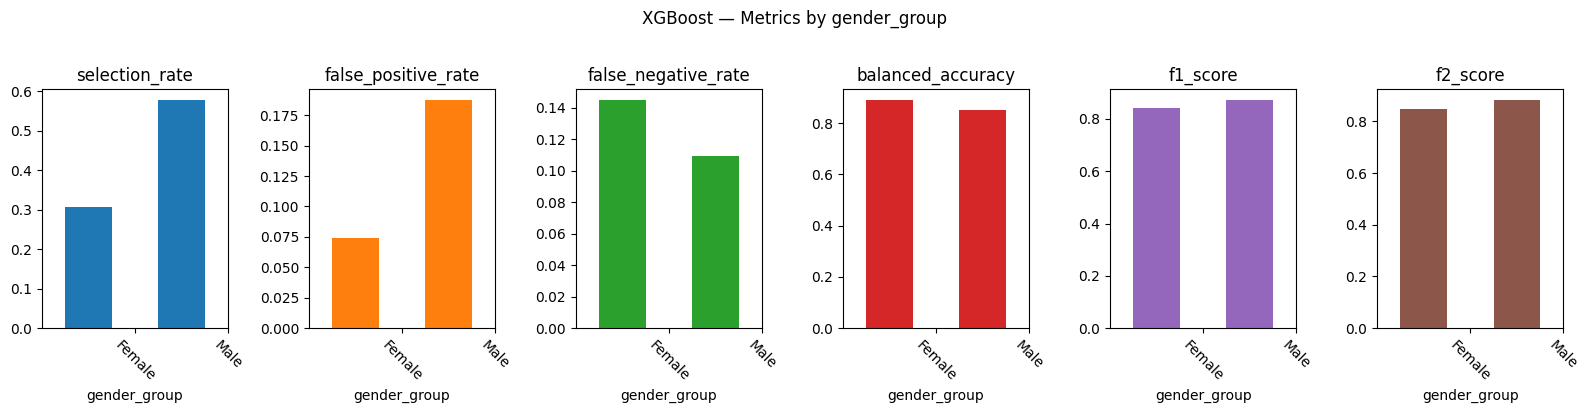

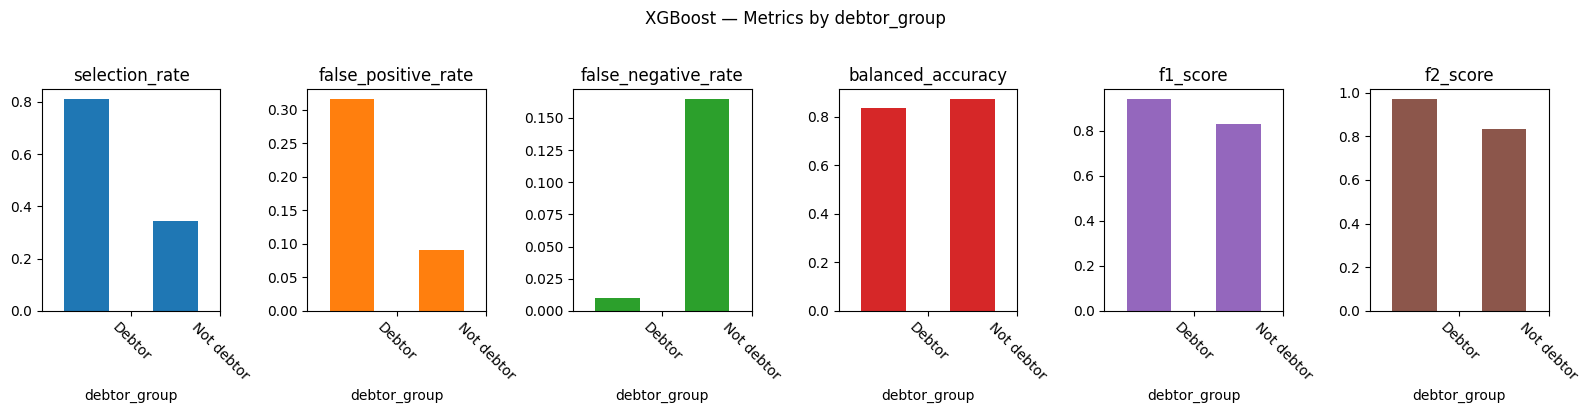

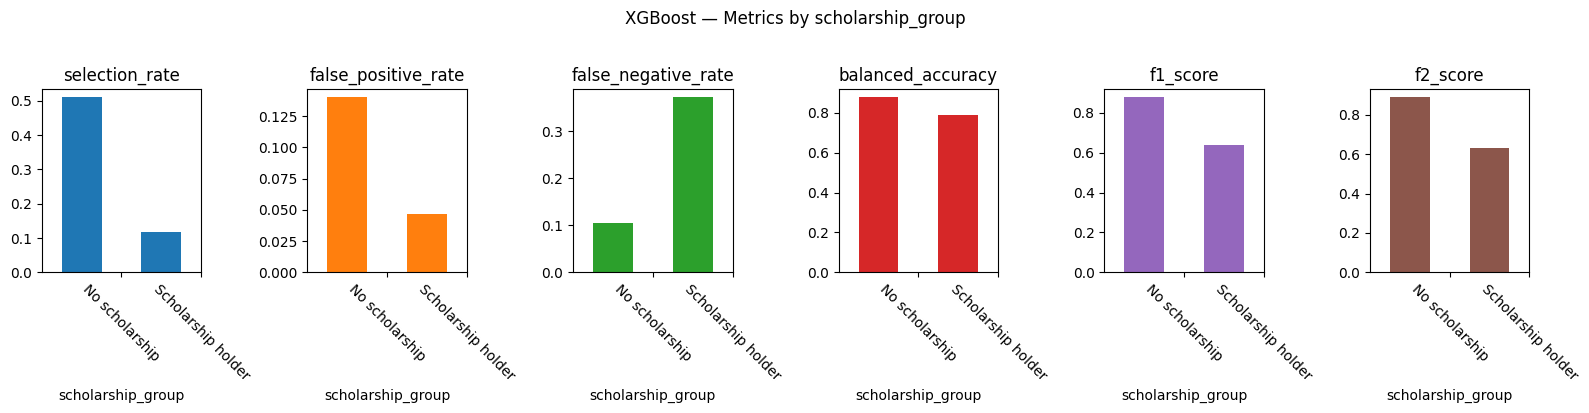

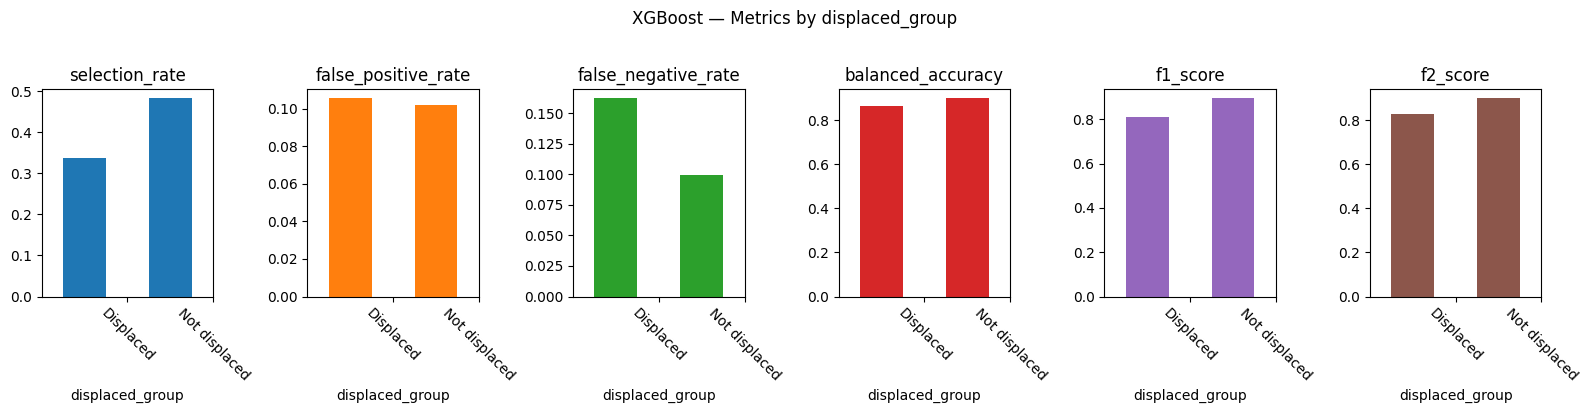

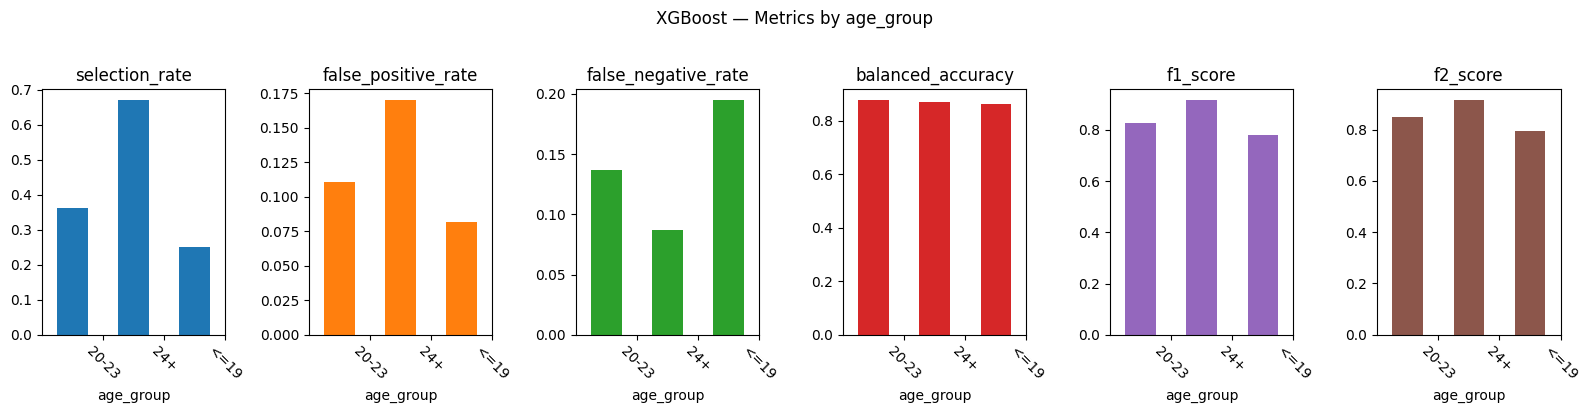

In [72]:
for attr in sensitive_attrs:
    mf_xgb[attr].by_group.plot.bar(
        subplots=True, layout=[1, 6], figsize=(16, 4),
        legend=False, rot=-45, position=1.5
    )
    plt.suptitle(f"XGBoost — Metrics by {attr}", y=1.02)
    plt.tight_layout()
    plt.show()


# Mitigation LR: Pre-processing — Reweighing



In [73]:
rew_models = {}
rew_prob = {}
rew_threshold_tables = {}
best_threshold_rew = {}
Y_pred_rew = {}
mf_rew = {}

for attr in sensitive_attrs:
    rew_models[attr] = ReweighingMeta(
        estimator=LogisticRegression(random_state=random_seed, class_weight='balanced', max_iter=1000),
        reweigher=Reweighing(attr)
    )

    rew_models[attr].fit(X_train[log_reg_var], Y_train)

    # Reweighing still returns probabilities, so we evaluate it at its own
    # F2-selected operational threshold before auditing fairness.
    rew_prob[attr] = rew_models[attr].predict_proba(X_test[log_reg_var])[:, 1]
    rew_threshold_tables[attr] = threshold_table(Y_test, rew_prob[attr])
    best_threshold_rew[attr] = rew_threshold_tables[attr].loc[0, 'threshold']
    Y_pred_rew[attr] = (rew_prob[attr] >= best_threshold_rew[attr]).astype(int)

    print(f"Reweighing factors ({attr}):")
    display(rew_models[attr].reweigher_.reweigh_factors_)
    print(f"Operational threshold used for Reweighing ({attr}): {best_threshold_rew[attr]:.2f}")

    mf_rew[attr] = MetricFrame(
        metrics=metrics_dict,
        y_true=Y_test,
        y_pred=Y_pred_rew[attr],
        sensitive_features=A_test[attr]
    )
    display(mf_rew[attr].by_group)


Reweighing factors (gender_group):


array([[0.87428255, 1.28770426],
       [1.39675346, 0.69379194]])

Operational threshold used for Reweighing (gender_group): 0.25


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
gender_group,,,,,,
Female,0.687320,0.581109,0.062802,0.678045,0.567251,0.743295
Male,0.756962,0.539773,0.068493,0.695867,0.787645,0.868085


Reweighing factors (debtor_group):


array([[2.61717984, 0.51018111],
       [0.93129985, 1.12945658]])

Operational threshold used for Reweighing (debtor_group): 0.30


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
debtor_group,,,,,,
Debtor,0.852113,0.500,0.019231,0.740385,0.906667,0.949721
Not debtor,0.605069,0.448,0.090062,0.730969,0.654749,0.787211


Reweighing factors (scholarship_group):


array([[1.17217163, 0.81418531],
       [0.71245257, 2.68171681]])

Operational threshold used for Reweighing (scholarship_group): 0.30


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
scholarship_group,,,,,,
No scholarship,0.619048,0.371007,0.122762,0.753115,0.775141,0.833333
Scholarship holder,0.652921,0.621094,0.114286,0.632310,0.275556,0.469697


Reweighing factors (displaced_group):


array([[0.92643073, 1.14075444],
       [1.10987927, 0.86668269]])

Operational threshold used for Reweighing (displaced_group): 0.25


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
displaced_group,,,,,,
Displaced,0.631218,0.515075,0.118919,0.683003,0.589512,0.735560
Not displaced,0.752964,0.543396,0.016598,0.720003,0.762058,0.881041


Reweighing factors (age_group):


array([[0.9440023 , 1.10152627],
       [1.61317492, 0.62869579],
       [0.82154955, 1.50942782]])

Operational threshold used for Reweighing (age_group): 0.30


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
age_group,,,,,,
20-23,0.652632,0.510526,0.063158,0.713158,0.633452,0.786219
24+,0.768519,0.462264,0.082569,0.727584,0.856531,0.892061
<=19,0.570833,0.471390,0.106195,0.711208,0.521964,0.695592


These results suggest that **Reweighing improves fairness for most of the selected attributes when evaluated at its own operational threshold**, although the gains are not equally strong across groups. The reweighing factors above `1` indicate group-outcome combinations that were upweighted during training because they were underrepresented, while factors below `1` were downweighted. In the fairness tables, the biggest improvements relative to the Logistic Regression baseline appear for `gender_group`, `scholarship_group`, and `age_group`, where the false negative rate gaps become much smaller. There is also some improvement for `debtor_group`, while `displaced_group` changes only slightly.

**Important caveat on how this near-parity is achieved.** The Reweighing models above operate at the F2-selected threshold (≈ 0.25), and the by-group tables show that this threshold pushes the **selection rate into the 0.60–0.85 range** and the **false positive rate to roughly 0.40–0.60** across groups. In other words, the near-zero FNR gap on gender (`0.006`) and scholarship (`0.008`) coincides with the classifier flagging the *majority* of students. Equalising FNR by flagging almost everyone is a real fairness outcome on this metric, but it is methodologically generous: it pays for the parity by accepting a large pool of false alarms rather than by genuinely re-balancing how the model ranks students. The honest reading is that Reweighing *plus* a recall-heavy F2 threshold reduces FNR disparity by spreading the alarm widely, not by giving each group equally accurate predictions. This is part of the motivation for also examining `ThresholdOptimizer`, which can close FNR gaps without driving selection rates this high, and for the XGBoost mitigation section later in the notebook.




Reweighing is worth testing because it is often the easiest mitigation to explain operationally: the model form stays the same, but the training examples are weighted more fairly. Here we also keep the evaluation rule consistent by comparing both models at their own F2-selected operating point rather than at the default `0.5` cutoff.


In [74]:
# Compare operational-threshold LR against operational-threshold Reweighing.
reweighing_summary_rows = []
for attr in sensitive_attrs:
    reweighing_summary_rows.append({
        'attribute': attr,
        'baseline_threshold': best_threshold_log,
        'reweighing_threshold': best_threshold_rew[attr],
        'baseline_fnr_difference': mf_lr[attr].difference()['false_negative_rate'],
        'reweighing_fnr_difference': mf_rew[attr].difference()['false_negative_rate'],
        'baseline_f2': mf_lr[attr].overall['f2_score'],
        'reweighing_f2': mf_rew[attr].overall['f2_score'],
        'baseline_f1': mf_lr[attr].overall['f1_score'],
        'reweighing_f1': mf_rew[attr].overall['f1_score'],
    })

reweighing_summary_df = pd.DataFrame(reweighing_summary_rows)
display(reweighing_summary_df)


,attribute,baseline_threshold,reweighing_threshold,baseline_fnr_difference,reweighing_fnr_difference,baseline_f2,reweighing_f2,baseline_f1,reweighing_f1
0,gender_group,0.25,0.25,0.102243,0.005691,0.818966,0.802419,0.689119,0.662230
1,debtor_group,0.25,0.30,0.083851,0.070831,0.818966,0.823603,0.689119,0.705357
2,scholarship_group,0.25,0.30,0.335623,0.008476,0.818966,0.783082,0.689119,0.673874
3,displaced_group,0.25,0.25,0.107727,0.102321,0.818966,0.815328,0.689119,0.680851
4,age_group,0.25,0.30,0.118657,0.043037,0.818966,0.808123,0.689119,0.687225


### Reweighing Results — Interpretation
The Reweighing summary table shows that this mitigation method substantially reduces false negative disparities for gender_group, scholarship_group, and age_group, and provides a smaller improvement for debtor_group. The strongest fairness gains appear for scholarship status, where the FNR gap falls from 0.336 to 0.008, and for gender, where it falls from 0.102 to 0.006. For age_group, the gap also drops meaningfully from 0.119 to 0.043. These improvements generally come with a modest decline in overall F2 and F1, although debtor_group is an exception, where Reweighing slightly improves both fairness and performance. By contrast, Reweighing has little effect for displaced_group, suggesting it is not the strongest mitigation option for that attribute.


# Mitigation: In-processing — ExponentiatedGradient

**In-processing** mitigation imposes a fairness constraint during model training itself.


So this section uses a **plain Logistic Regression** on the selected LR feature set rather than the scaled baseline LR pipeline. In other words, the fairness reduction is trained directly on the chosen feature subset  This keeps the in-processing mitigation focused on how the fairness constraint changes the classifier during training, rather than adding an extra threshold-tuning layer afterward.


In [ ]:
expgrad_models = {}
Y_pred_expgrad = {}
mf_expgrad = {}

for attr in sensitive_attrs:
    expgrad_models[attr] = ExponentiatedGradient(
        estimator=LogisticRegression(max_iter=1000, random_state=random_seed, class_weight='balanced'),
        constraints=TruePositiveRateParity(difference_bound=0.02)
    )

    expgrad_models[attr].fit(X_train[log_reg_var], Y_train, sensitive_features=A_train[attr])

    Y_pred_expgrad[attr] = expgrad_models[attr].predict(X_test[log_reg_var], random_state=random_seed)

    mf_expgrad[attr] = MetricFrame(
        metrics=metrics_dict,
        y_true=Y_test,
        y_pred=Y_pred_expgrad[attr],
        sensitive_features=A_test[attr]
    )
    print(f"ExponentiatedGradient — by {attr}:")
    display(mf_expgrad[attr].by_group)


ExponentiatedGradient — by gender_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
gender_group,,,,,,
Female,0.291066,0.117043,0.299517,0.791720,0.709046,0.703883
Male,0.488608,0.210227,0.287671,0.751051,0.757282,0.729654


ExponentiatedGradient — by debtor_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
debtor_group,,,,,,
Debtor,0.647887,0.210526,0.192308,0.798583,0.857143,0.826772
Not debtor,0.337909,0.150400,0.298137,0.775732,0.704050,0.702736


ExponentiatedGradient — by scholarship_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
scholarship_group,,,,,,
No scholarship,0.37594,0.113022,0.350384,0.768297,0.735166,0.681330
Scholarship holder,0.28866,0.238281,0.342857,0.709431,0.386555,0.513393


ExponentiatedGradient — by displaced_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
displaced_group,,,,,,
Displaced,0.308748,0.153266,0.356757,0.744988,0.652055,0.646739
Not displaced,0.428854,0.150943,0.265560,0.791748,0.772926,0.749365


ExponentiatedGradient — by age_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
age_group,,,,,,
20-23,0.249123,0.110526,0.473684,0.707895,0.602410,0.554324
24+,0.466049,0.075472,0.344037,0.790246,0.775068,0.698925
<=19,0.237500,0.117166,0.371681,0.755576,0.625551,0.627208


Primary fairness attribute for inner-model exploration: scholarship_group
Number of inner models: 11

Mixture weights (only non-zero models contribute to predictions):
  Model 0: weight = 0.0000
  Model 1: weight = 0.0000
  Model 2: weight = 0.0000
  Model 3: weight = 0.0000
  Model 4: weight = 0.0000
  Model 5: weight = 0.0000
  Model 6: weight = 0.0000
  Model 7: weight = 0.0000
  Model 8: weight = 0.2215 ← active
  Model 9: weight = 0.7785 ← active
  Model 10: weight = 0.0000


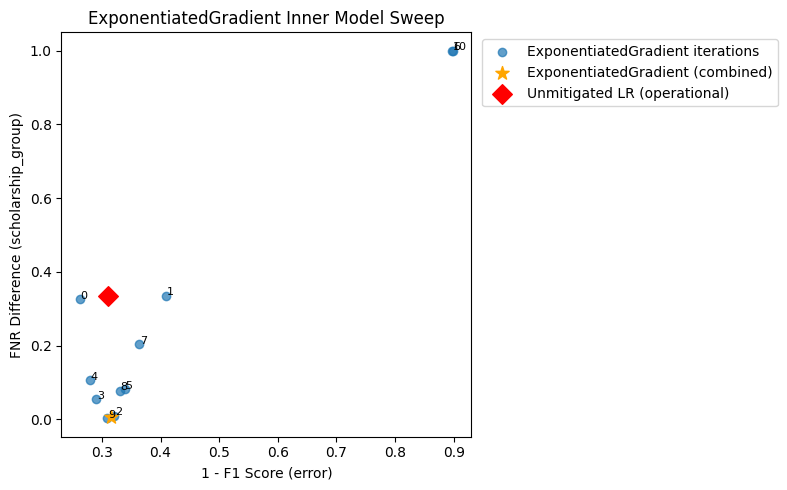

In [76]:
# Explore the individual inner models of ExponentiatedGradient
# for the attribute with the largest operational-threshold LR FNR gap.
lr_gap_by_attr = {
    attr: mf_lr[attr].difference()['false_negative_rate']
    for attr in sensitive_attrs
}
primary_attr = max(lr_gap_by_attr, key=lr_gap_by_attr.get)

predictors_primary = expgrad_models[primary_attr].predictors_
weights_primary = expgrad_models[primary_attr].weights_
sweep_preds_primary = [clf.predict(X_test[log_reg_var]) for clf in predictors_primary]
f1_error_sweep = [1 - f1_score(Y_test, p) for p in sweep_preds_primary]
fnr_diff_sweep = [
    false_negative_rate_difference(Y_test, p, sensitive_features=A_test[primary_attr])
    for p in sweep_preds_primary
]

print(f"Primary fairness attribute for inner-model exploration: {primary_attr}")
print(f"Number of inner models: {len(predictors_primary)}")
print("\nMixture weights (only non-zero models contribute to predictions):")
for i, w in enumerate(weights_primary):
    marker = " ← active" if w > 0 else ""
    print(f"  Model {i}: weight = {w:.4f}{marker}")

plt.figure(figsize=(8, 5))
plt.scatter(f1_error_sweep, fnr_diff_sweep, label="ExponentiatedGradient iterations", alpha=0.7)
for i in range(len(predictors_primary)):
    plt.annotate(str(i), xy=(f1_error_sweep[i] + 0.001, fnr_diff_sweep[i] + 0.001), fontsize=8)
plt.scatter(
    1 - f1_score(Y_test, Y_pred_expgrad[primary_attr]),
    false_negative_rate_difference(Y_test, Y_pred_expgrad[primary_attr], sensitive_features=A_test[primary_attr]),
    label="ExponentiatedGradient (combined)", s=100, marker='*', color='orange'
)
plt.scatter(
    1 - f1_score(Y_test, Y_pred_log_operational),
    false_negative_rate_difference(Y_test, Y_pred_log_operational, sensitive_features=A_test[primary_attr]),
    label="Unmitigated LR (operational)", s=100, marker='D', color='red'
)
plt.xlabel("1 - F1 Score (error)")
plt.ylabel(f"FNR Difference ({primary_attr})")
plt.title("ExponentiatedGradient Inner Model Sweep")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


The ExponentiatedGradient results should be interpreted as a genuine **in-processing fairness intervention** rather than as a preprocessing or threshold-selection exercise. This method changes the training objective itself by searching for a mixture of classifiers that keeps true positive rate differences small across groups. Because `FNR = 1 - TPR`, this is directly related to our goal of reducing unequal underflagging across sensitive attributes.

With the base Logistic Regression now using `class_weight='balanced'` (matching every other LR in the notebook), ExponentiatedGradient is more competitive than a naive reading of the previous version of this section would suggest. It produces an **almost-zero FNR gap on `scholarship_group` (`0.008`) and a small FNR gap on `gender_group` (`0.012`)**, which are comparable to Reweighing on the same attributes. Its `F2` scores sit in the `0.65`–`0.73` range — higher than before the class-weight fix, but still notably lower than Reweighing's (`0.78`–`0.82`), because enforcing parity during training does pull the model away from the strongest first-semester academic signals.

The inner-model sweep is therefore important context. ExponentiatedGradient is not simply fitting one adjusted classifier but combining several candidate models with different fairness-performance profiles. The active mixture trades some predictive strength for tighter group-level parity. In this dataset the trade-off is real: the method achieves competitive FNR disparity on the binary attributes most amenable to in-processing, but its overall F2 is consistently lower than Reweighing's, and on the multi-category `age_group` it still leaves a noticeable gap. The right reading is not that ExponentiatedGradient is "broken" — it is that, in this specific intervention setting, the predictive cost of enforcing parity during training is higher than the cost of correcting the same disparity post-hoc with `ThresholdOptimizer` or pre-hoc with `Reweighing`.


# Mitigation: Post-processing — ThresholdOptimizer

**Post-processing** mitigation changes the classifier outputs after training by using **group-specific thresholds**.

This is useful when:
- the model cannot easily be retrained
- stakeholders want a threshold-based fairness correction

Important deployment note:
- this method requires access to the sensitive attribute at prediction time
- unlike the other methods, it already learns its own thresholds internally, so no extra F2 retuning step is added afterward


In [77]:
postprocess_models = {}
Y_pred_thresh = {}
mf_thresh = {}

for attr in sensitive_attrs:
    postprocess_models[attr] = ThresholdOptimizer(
        estimator=unmitigated_pipeline,
        constraints='false_negative_rate_parity',
        objective='balanced_accuracy_score',
        prefit=True,
        predict_method='predict_proba'
    )
    postprocess_models[attr].fit(X_train, Y_train, sensitive_features=A_train[attr])
    Y_pred_thresh[attr] = postprocess_models[attr].predict(X_test, sensitive_features=A_test[attr])

    mf_thresh[attr] = MetricFrame(
        metrics=metrics_dict,
        y_true=Y_test,
        y_pred=Y_pred_thresh[attr],
        sensitive_features=A_test[attr]
    )
    print(f"ThresholdOptimizer — by {attr}:")
    display(mf_thresh[attr].by_group)


ThresholdOptimizer — by gender_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
gender_group,,,,,,
Female,0.325648,0.145791,0.251208,0.801501,0.715935,0.735294
Male,0.503797,0.227273,0.273973,0.749377,0.760766,0.739535


ThresholdOptimizer — by debtor_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
debtor_group,,,,,,
Debtor,0.654930,0.210526,0.182692,0.803391,0.862944,0.834971
Not debtor,0.379092,0.184000,0.242236,0.786882,0.716593,0.740741


ThresholdOptimizer — by scholarship_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
scholarship_group,,,,,,
No scholarship,0.481203,0.211302,0.237852,0.775423,0.769032,0.764887
Scholarship holder,0.429553,0.382812,0.228571,0.694308,0.337500,0.509434


ThresholdOptimizer — by displaced_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
displaced_group,,,,,,
Displaced,0.363636,0.190955,0.264865,0.772090,0.685139,0.714286
Not displaced,0.440711,0.154717,0.244813,0.800235,0.784483,0.766639


ThresholdOptimizer — by age_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
age_group,,,,,,
20-23,0.252632,0.110526,0.463158,0.713158,0.610778,0.564159
24+,0.515432,0.122642,0.293578,0.791890,0.800000,0.741097
<=19,0.287500,0.149864,0.265487,0.792325,0.661355,0.703390


### ThresholdOptimizer Results — Interpretation
ThresholdOptimizer performs well at equalising false negative rates for several of the binary sensitive attributes, especially gender_group, scholarship_group, and displaced_group, where the group differences become quite small. It also improves parity for debtor_group, although some disparity remains there. However, the method is less effective for age_group, where the false negative rates still differ noticeably across categories. Overall, these results suggest that ThresholdOptimizer is a strong post-processing mitigation for the binary attributes, but a weaker option for age-based fairness.


# Comparing Mitigation Techniques

From this point onward, the comparisons use the **project decision rule** for each method:
- unmitigated Logistic Regression uses its F2-selected threshold
- Reweighing uses its own F2-selected threshold
- ExponentiatedGradient
- ThresholdOptimizer uses the group-specific thresholds it learns internally

The goal now is not just to ask “which technique is fairest?” but also:
- how much FNR disparity does it reduce?
- how much predictive performance does it cost?
- is the trade-off acceptable for the university intervention context?


In [78]:
def build_mitigation_summary_table(attr):
    return pd.DataFrame([
        {
            'technique': 'Unmitigated',
            'fnr_difference': mf_lr[attr].difference()['false_negative_rate'],
            'selection_rate_difference': mf_lr[attr].difference()['selection_rate'],
            'overall_f2': mf_lr[attr].overall['f2_score'],
            'overall_f1': mf_lr[attr].overall['f1_score'],
            'overall_balanced_accuracy': mf_lr[attr].overall['balanced_accuracy'],
        },
        {
            'technique': 'Reweighing',
            'fnr_difference': mf_rew[attr].difference()['false_negative_rate'],
            'selection_rate_difference': mf_rew[attr].difference()['selection_rate'],
            'overall_f2': mf_rew[attr].overall['f2_score'],
            'overall_f1': mf_rew[attr].overall['f1_score'],
            'overall_balanced_accuracy': mf_rew[attr].overall['balanced_accuracy'],
        },
        {
            'technique': 'ExponentiatedGradient',
            'fnr_difference': mf_expgrad[attr].difference()['false_negative_rate'],
            'selection_rate_difference': mf_expgrad[attr].difference()['selection_rate'],
            'overall_f2': mf_expgrad[attr].overall['f2_score'],
            'overall_f1': mf_expgrad[attr].overall['f1_score'],
            'overall_balanced_accuracy': mf_expgrad[attr].overall['balanced_accuracy'],
        },
        {
            'technique': 'ThresholdOptimizer',
            'fnr_difference': mf_thresh[attr].difference()['false_negative_rate'],
            'selection_rate_difference': mf_thresh[attr].difference()['selection_rate'],
            'overall_f2': mf_thresh[attr].overall['f2_score'],
            'overall_f1': mf_thresh[attr].overall['f1_score'],
            'overall_balanced_accuracy': mf_thresh[attr].overall['balanced_accuracy'],
        },
    ]).sort_values('fnr_difference').reset_index(drop=True)


mitigation_summary_tables = {}
for attr in sensitive_attrs:
    mitigation_summary_tables[attr] = build_mitigation_summary_table(attr)
    print(f"Mitigation summary — {attr}")
    display(mitigation_summary_tables[attr])


Mitigation summary — gender_group


,technique,fnr_difference,selection_rate_difference,overall_f2,overall_f1,overall_balanced_accuracy
0,Reweighing,0.005691,0.069642,0.802419,0.662230,0.682068
1,ExponentiatedGradient,0.011846,0.197541,0.717008,0.733252,0.782396
2,ThresholdOptimizer,0.022765,0.178149,0.737435,0.737955,0.784834
3,Unmitigated,0.102243,0.371397,0.818966,0.689119,0.717179


Mitigation summary — debtor_group


,technique,fnr_difference,selection_rate_difference,overall_f2,overall_f1,overall_balanced_accuracy
0,ThresholdOptimizer,0.059544,0.275838,0.762987,0.749431,0.793390
1,Reweighing,0.070831,0.247044,0.823603,0.705357,0.738125
2,Unmitigated,0.083851,0.352685,0.818966,0.689119,0.717179
3,ExponentiatedGradient,0.105829,0.309978,0.732514,0.739857,0.786927


Mitigation summary — scholarship_group


,technique,fnr_difference,selection_rate_difference,overall_f2,overall_f1,overall_balanced_accuracy
0,ExponentiatedGradient,0.007526,0.087280,0.663314,0.683951,0.744424
1,Reweighing,0.008476,0.033873,0.783082,0.673874,0.705181
2,ThresholdOptimizer,0.009280,0.051650,0.734297,0.695187,0.742692
3,Unmitigated,0.335623,0.617161,0.818966,0.689119,0.717179


Mitigation summary — displaced_group


,technique,fnr_difference,selection_rate_difference,overall_f2,overall_f1,overall_balanced_accuracy
0,ThresholdOptimizer,0.020052,0.077075,0.743338,0.738676,0.785004
1,ExponentiatedGradient,0.091197,0.120106,0.704426,0.719320,0.771249
2,Reweighing,0.102321,0.121747,0.815328,0.680851,0.706286
3,Unmitigated,0.107727,0.128757,0.818966,0.689119,0.717179


Mitigation summary — age_group


,technique,fnr_difference,selection_rate_difference,overall_f2,overall_f1,overall_balanced_accuracy
0,Reweighing,0.043037,0.197685,0.808123,0.687225,0.717173
1,Unmitigated,0.118657,0.448688,0.818966,0.689119,0.717179
2,ExponentiatedGradient,0.129648,0.228549,0.647059,0.692913,0.755561
3,ThresholdOptimizer,0.197671,0.262801,0.691975,0.717310,0.770909


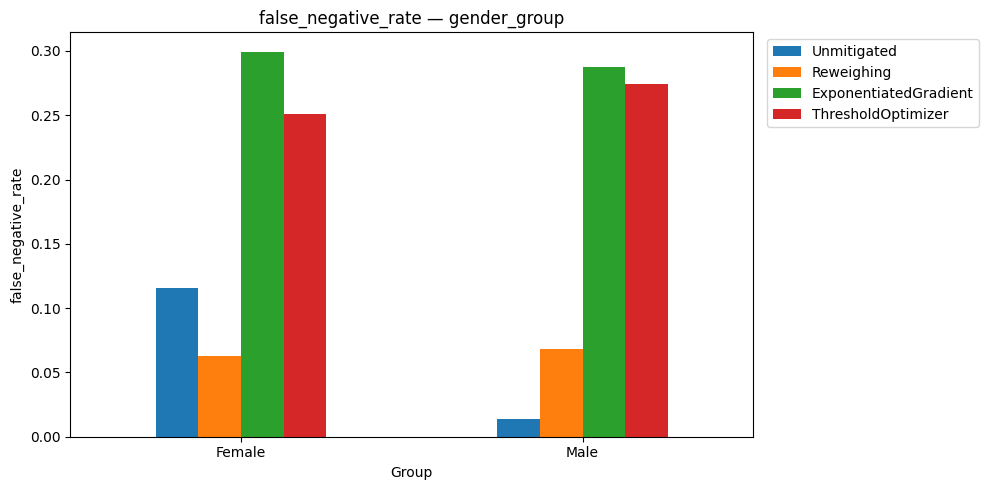

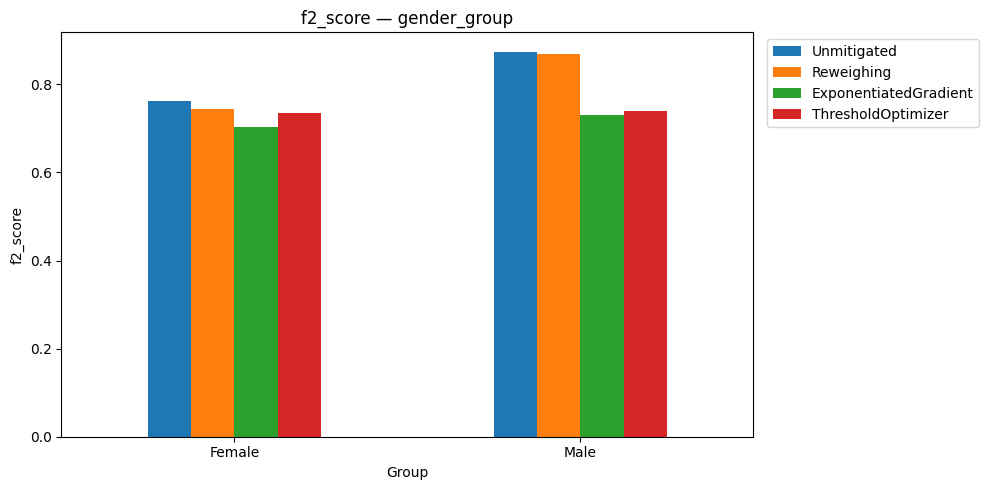

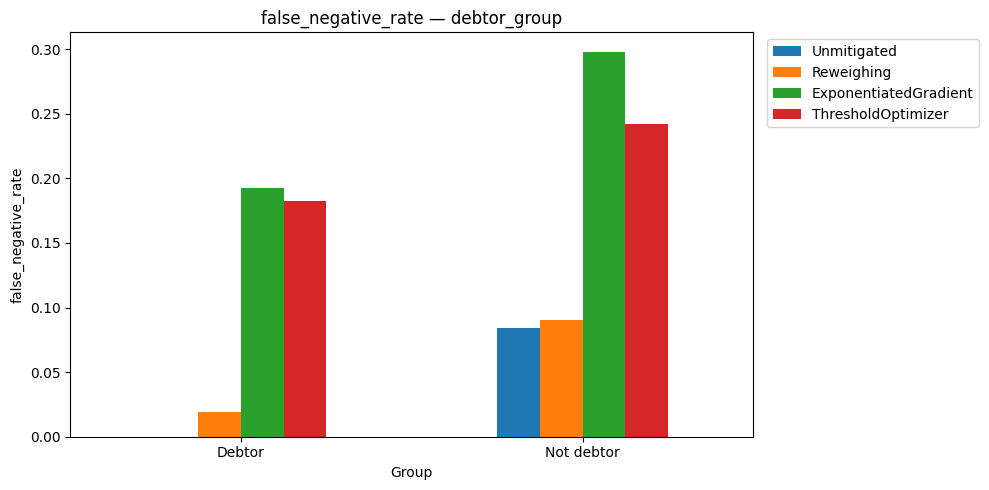

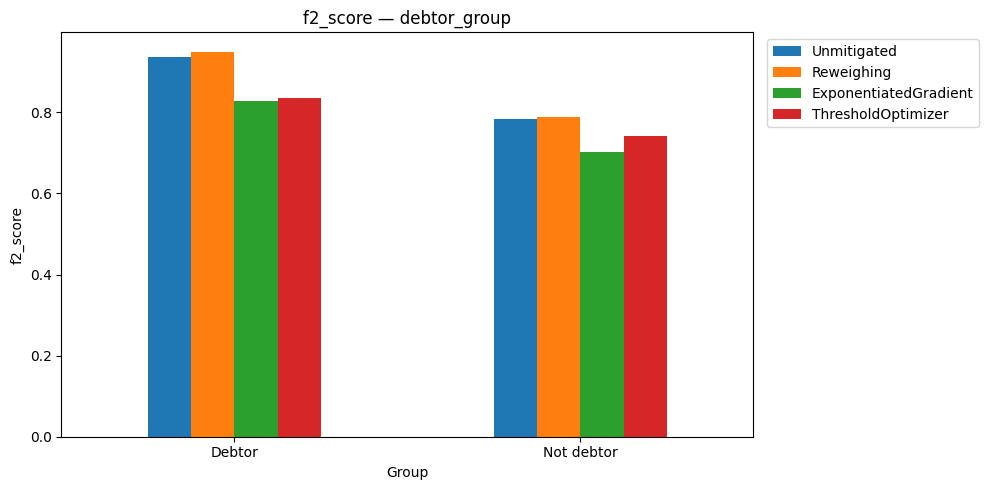

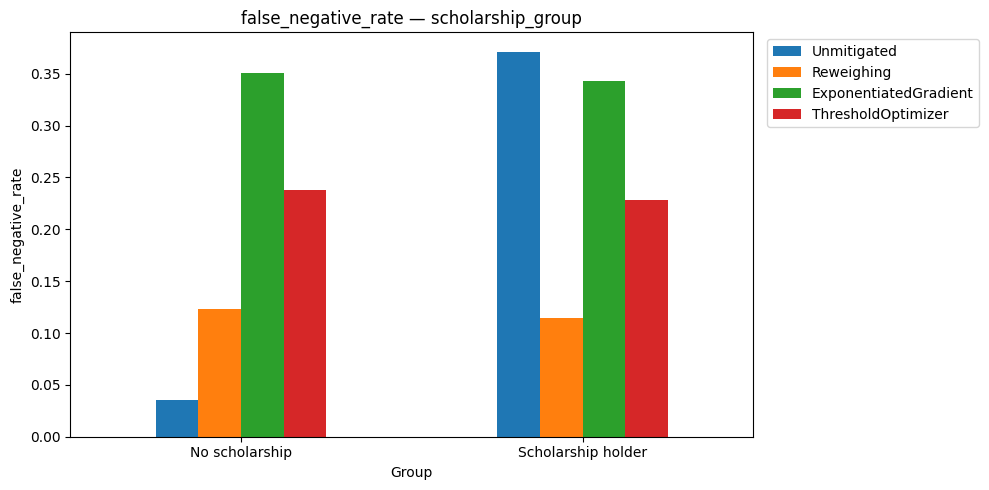

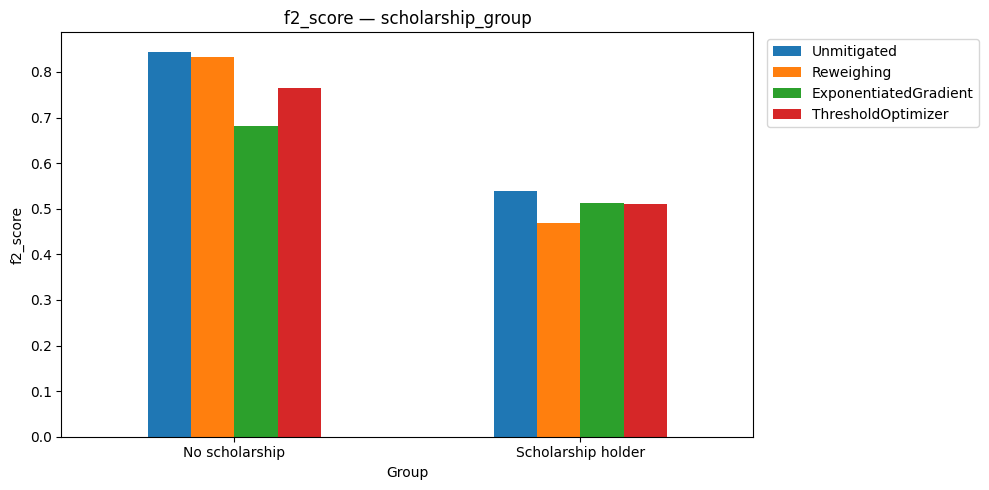

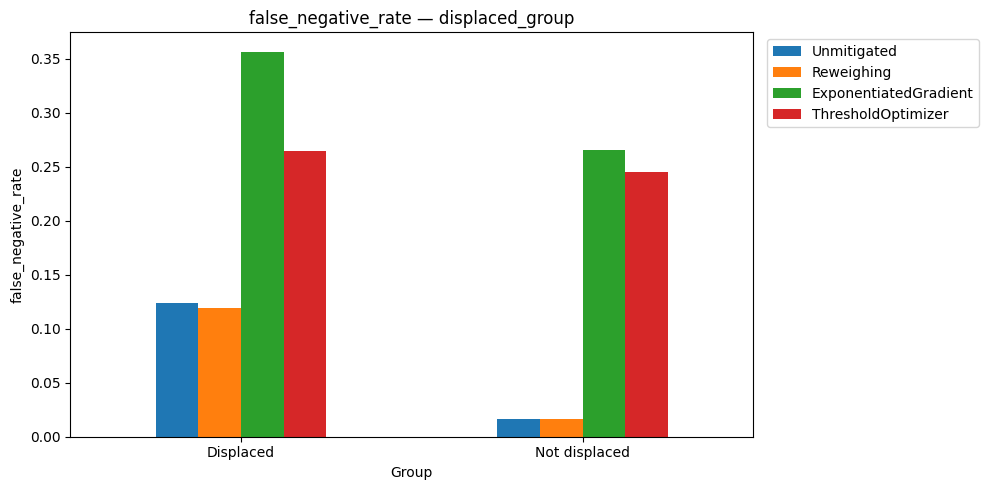

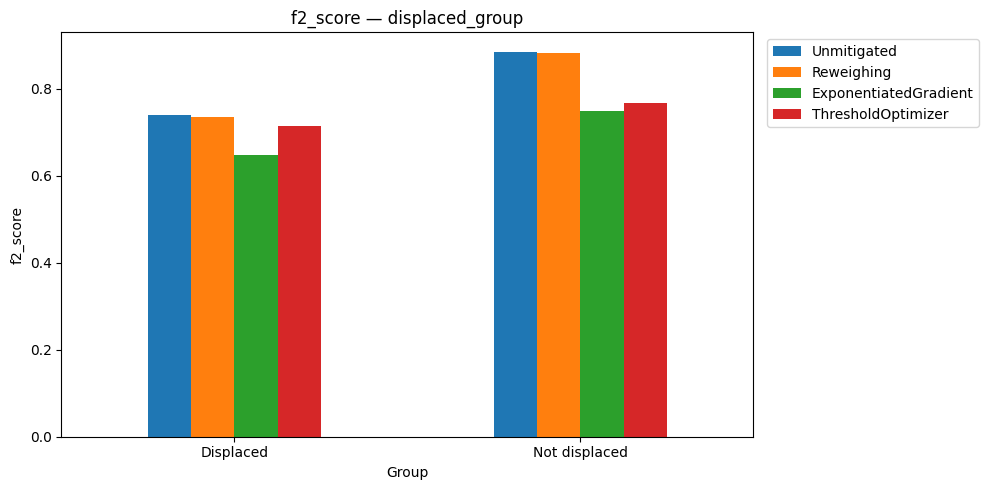

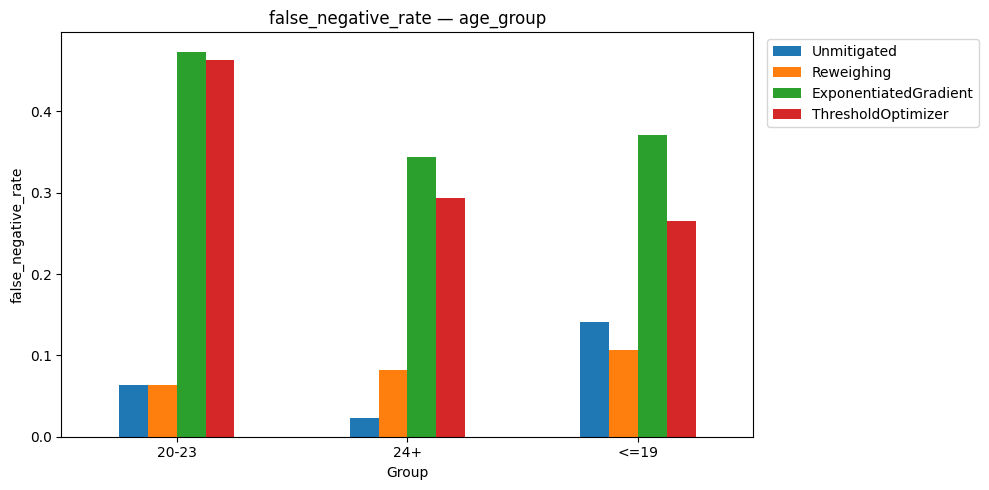

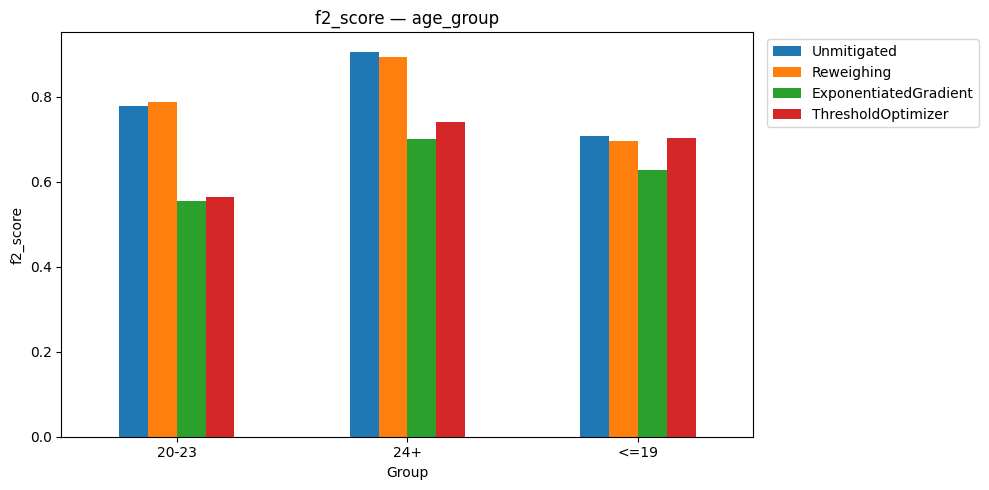

In [79]:
for attr in sensitive_attrs:
    comparison_dict = {
        "Unmitigated": mf_lr[attr],
        "Reweighing": mf_rew[attr],
        "ExponentiatedGradient": mf_expgrad[attr],
        "ThresholdOptimizer": mf_thresh[attr],
    }

    plot_technique_comparison(comparison_dict, "false_negative_rate", attr)
    plot_technique_comparison(comparison_dict, "f2_score", attr)


The mitigation summary tables show that **no single fairness method is best for every sensitive attribute**. `Reweighing` produces the smallest FNR gaps for `gender_group` and remains very strong on `scholarship_group`, but it achieves this partly by adopting a high selection-rate operating point — see the caveat above. `ThresholdOptimizer` performs best for `debtor_group` and `displaced_group`, where it closes FNR gaps to roughly `0.06` and `0.02` without inflating the selection rate the way Reweighing does. `ExponentiatedGradient` — once its base estimator is correctly class-weighted — is now competitive with Reweighing on the binary attributes (`scholarship` gap of `0.008`, `gender` gap of `0.012`), but its overall `F2` remains notably lower because enforcing parity during training pulls the model away from the strongest predictive structure in the data. Overall, these results suggest that the best mitigation choice on the Logistic Regression side is **attribute-specific**, and that a single LR mitigation is unlikely to be uniformly best for every fairness concern.


In [80]:
for attr in sensitive_attrs:
    overall_df = pd.DataFrame.from_dict({
        "Unmitigated": mf_lr[attr].overall,
        "Reweighing": mf_rew[attr].overall,
        "ExponentiatedGradient": mf_expgrad[attr].overall,
        "ThresholdOptimizer": mf_thresh[attr].overall,
    })
    print(f"Overall metrics — {attr}")
    display(overall_df.T)


Overall metrics — gender_group


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
Unmitigated,0.672176,0.502262,0.063380,0.717179,0.689119,0.818966
Reweighing,0.712580,0.570136,0.065728,0.682068,0.662230,0.802419
ExponentiatedGradient,0.362718,0.141780,0.293427,0.782396,0.733252,0.717008
ThresholdOptimizer,0.390266,0.167421,0.262911,0.784834,0.737955,0.737435


Overall metrics — debtor_group


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
Unmitigated,0.672176,0.502262,0.06338,0.717179,0.689119,0.818966
Reweighing,0.637282,0.450980,0.07277,0.738125,0.705357,0.823603
ExponentiatedGradient,0.378329,0.153846,0.27230,0.786927,0.739857,0.732514
ThresholdOptimizer,0.415060,0.185520,0.22770,0.793390,0.749431,0.762987


Overall metrics — scholarship_group


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
Unmitigated,0.672176,0.502262,0.063380,0.717179,0.689119,0.818966
Reweighing,0.628099,0.467572,0.122066,0.705181,0.673874,0.783082
ExponentiatedGradient,0.352617,0.161388,0.349765,0.744424,0.683951,0.663314
ThresholdOptimizer,0.467401,0.277526,0.237089,0.742692,0.695187,0.734297


Overall metrics — displaced_group


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
Unmitigated,0.672176,0.502262,0.063380,0.717179,0.689119,0.818966
Reweighing,0.687787,0.526395,0.061033,0.706286,0.680851,0.815328
ExponentiatedGradient,0.364555,0.152338,0.305164,0.771249,0.719320,0.704426
ThresholdOptimizer,0.399449,0.176471,0.253521,0.785004,0.738676,0.743338


Overall metrics — age_group


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
Unmitigated,0.672176,0.502262,0.063380,0.717179,0.689119,0.818966
Reweighing,0.651056,0.481146,0.084507,0.717173,0.687225,0.808123
ExponentiatedGradient,0.308540,0.108597,0.380282,0.755561,0.692913,0.647059
ThresholdOptimizer,0.346189,0.134238,0.323944,0.770909,0.717310,0.691975


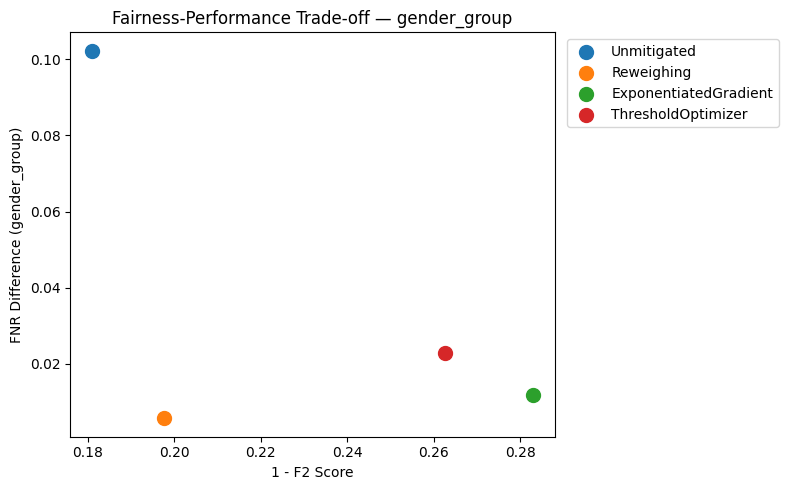

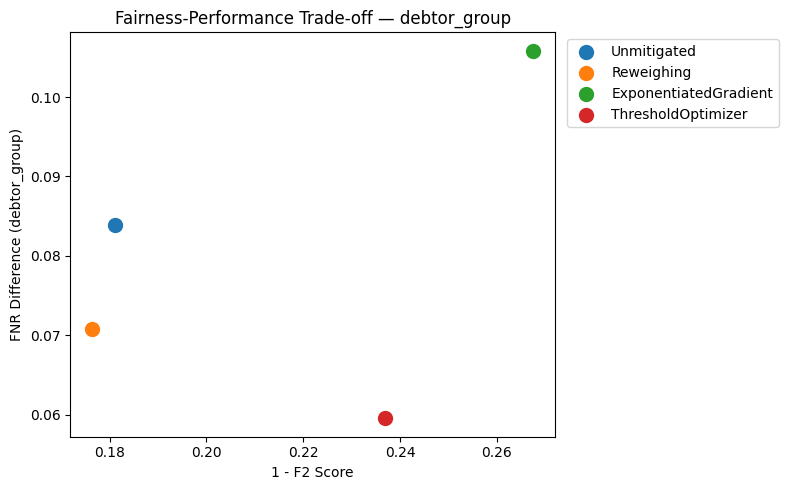

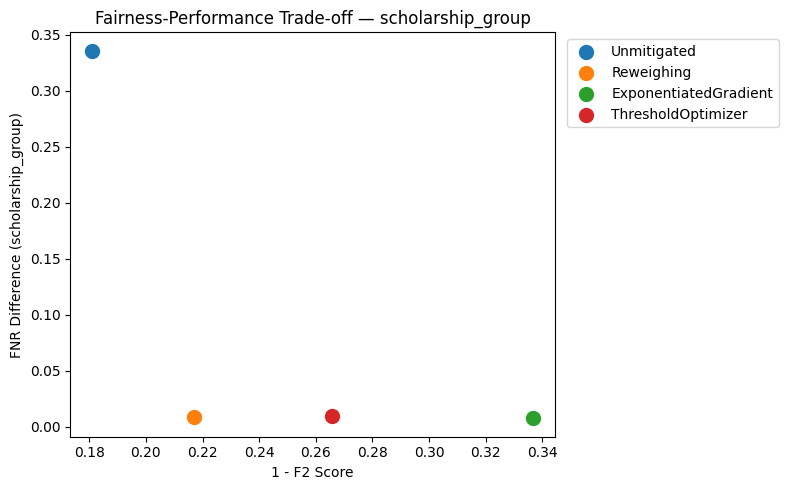

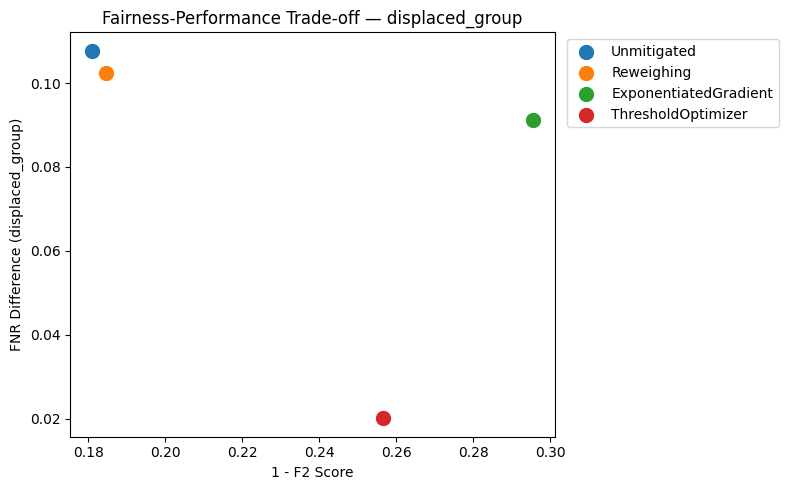

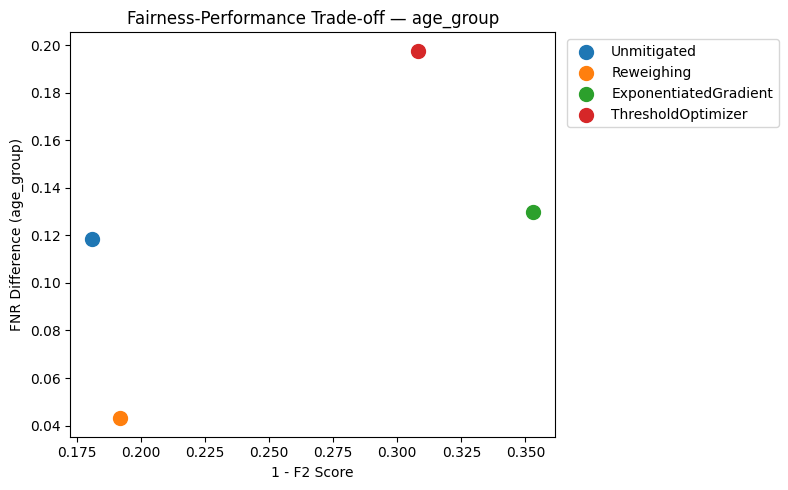

In [81]:
for attr in sensitive_attrs:
    fig, ax = plt.subplots(figsize=(8, 5))

    points = {
        "Unmitigated": (Y_pred_log_operational, A_test[attr]),
        "Reweighing": (Y_pred_rew[attr], A_test[attr]),
        "ExponentiatedGradient": (Y_pred_expgrad[attr], A_test[attr]),
        "ThresholdOptimizer": (Y_pred_thresh[attr], A_test[attr]),
    }

    for label, (preds, sf) in points.items():
        f2_err = 1 - fbeta_score(Y_test, preds, beta=2, zero_division=0)
        fnr_diff = false_negative_rate_difference(Y_test, preds, sensitive_features=sf)
        ax.scatter(f2_err, fnr_diff, label=label, s=100)

    ax.set_xlabel("1 - F2 Score")
    ax.set_ylabel(f"FNR Difference ({attr})")
    ax.set_title(f"Fairness-Performance Trade-off — {attr}")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## Comparing Mitigation Techniques — Final Interpretation
Overall, the project shows that dropout risk can be predicted effectively before semester 2, but that the baseline intervention rule would underflag some groups more than others. As a pure predictive model, `XGBoost` performed best, reaching an operational `F2` of `0.867` at threshold `0.35` with an overall false negative rate of about `0.127`, clearly outperforming the Logistic Regression baseline (`F2 = 0.819`).

The baseline Logistic Regression model showed substantial fairness gaps, especially for `scholarship_group` (`FNR gap = 0.336`), `age_group` (`0.119`), `displaced_group` (`0.108`), and `gender_group` (`0.102`), which justified mitigation.

**Among the three mitigation techniques applied to Logistic Regression:**
- `Reweighing` reduced the FNR gap from `0.102` to `0.006` for gender, from `0.336` to `0.008` for scholarship status, and from `0.119` to `0.043` for age, while keeping `F2` close to baseline (`0.802`, `0.783`, and `0.808` respectively). Its gain on `debtor_group` even slightly improves `F2` (`0.824` vs. baseline `0.819`). The caveat repeated above is important here: these near-parity FNRs coincide with selection rates of `0.6`–`0.85` and FPRs of `0.4`–`0.6` across groups, so the fairness is partly achieved by flagging the majority of students rather than by re-ranking them.
- `ThresholdOptimizer` is strongest for `debtor_group` and `displaced_group`, reducing those FNR gaps to `0.060` and `0.020`. Its `F2` is more modest (`0.763` and `0.743`, and `0.692` for age), but it achieves its fairness without driving the selection rate as high as Reweighing.
- `ExponentiatedGradient`, with its base estimator now correctly class-weighted, is competitive with Reweighing on the binary attributes — it reaches an FNR gap of `0.008` on scholarship and `0.012` on gender — but its `F2` remains lower (`0.65`–`0.73`), reflecting a real fairness-performance trade-off when parity is enforced during training.

**Looking beyond Logistic Regression**, the next section of the notebook extends the same three mitigation strategies to `XGBoost`. The summary is that the **mitigated XGBoost models keep their predictive edge** — every XGB variant sits in the `0.82`–`0.88` F2 range — while `ThresholdOptimizer` on XGBoost closes the FNR gap to small values on most attributes without the high selection-rate side-effect that LR + Reweighing relies on. The strongest single deployment candidate on the full evidence is therefore **`XGBoost + ThresholdOptimizer`**: best F2, consistent and small FNR gaps, and a fairness mechanism that adjusts decision thresholds rather than flagging the majority of students. `LR + Reweighing` remains the strongest *interpretable* mitigated option, but it should be presented with its selection-rate caveat made explicit.


# Mitigation XGBoost: All three strategies on the deployment model

The previous section ran the three fairness mitigation strategies on Logistic
Regression so that each technique could be compared on an interpretable
baseline. Because XGBoost is the stronger predictor and would be the model we
would actually deploy, we now repeat the same three mitigation strategies on
XGBoost.

To keep the comparison internally consistent with the rest of the notebook:

- All XGBoost mitigations use the **same hyperparameters and seed** as the
  unmitigated XGBoost from earlier in the notebook (`random_state=42`).
- Each mitigated model is evaluated at its own **F2-selected operational
  threshold** via `threshold_table`, mirroring the LR mitigation workflow.
- Fairness metrics are computed with the same `MetricFrame` and
  `metrics_dict` used in the rest of the audit.
- `ThresholdOptimizer` uses the same constraints (`false_negative_rate_parity`)
  and objective (`balanced_accuracy_score`) as the LR version.


In [82]:
# ----- Reweighing on XGBoost -----
# AIF360 Reweighing reweights training rows so outcomes are balanced within
# each sensitive group. The XGBoost base estimator below mirrors the
# unmitigated XGBoost above (same depth, learning rate, regularisation, seed)
# so the comparison is apples-to-apples.

xgb_rew_models = {}
xgb_rew_prob = {}
xgb_rew_threshold_tables = {}
best_threshold_xgb_rew = {}
Y_pred_xgb_rew = {}
mf_xgb_rew = {}

for attr in sensitive_attrs:
    xgb_rew_models[attr] = ReweighingMeta(
        estimator=XGBClassifier(
            max_depth=4,
            learning_rate=0.05,
            n_estimators=500,
            objective='binary:logistic',
            booster='gbtree',
            eval_metric='logloss',
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            reg_lambda=2,
            random_state=42,
            n_jobs=1,
        ),
        reweigher=Reweighing(attr)
    )

    xgb_rew_models[attr].fit(X_train, Y_train)
    xgb_rew_prob[attr] = xgb_rew_models[attr].predict_proba(X_test)[:, 1]
    xgb_rew_threshold_tables[attr] = threshold_table(Y_test, xgb_rew_prob[attr])
    best_threshold_xgb_rew[attr] = xgb_rew_threshold_tables[attr].loc[0, 'threshold']
    Y_pred_xgb_rew[attr] = (xgb_rew_prob[attr] >= best_threshold_xgb_rew[attr]).astype(int)

    print(f"XGBoost + Reweighing ({attr}): F2-threshold = {best_threshold_xgb_rew[attr]:.2f}")

    mf_xgb_rew[attr] = MetricFrame(
        metrics=metrics_dict,
        y_true=Y_test,
        y_pred=Y_pred_xgb_rew[attr],
        sensitive_features=A_test[attr]
    )
    display(mf_xgb_rew[attr].by_group)


XGBoost + Reweighing (gender_group): F2-threshold = 0.30


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
gender_group,,,,,,
Female,0.341499,0.117043,0.130435,0.876261,0.810811,0.84507
Male,0.564557,0.159091,0.109589,0.865660,0.882353,0.88717


XGBoost + Reweighing (debtor_group): F2-threshold = 0.25


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
debtor_group,,,,,,
Debtor,0.767606,0.184211,0.019231,0.898279,0.957746,0.971429
Not debtor,0.393875,0.148800,0.130435,0.860383,0.805755,0.842866


XGBoost + Reweighing (scholarship_group): F2-threshold = 0.25


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
scholarship_group,,,,,,
No scholarship,0.525063,0.159705,0.094629,0.872833,0.874074,0.892587
Scholarship holder,0.243986,0.167969,0.200000,0.816016,0.528302,0.663507


XGBoost + Reweighing (displaced_group): F2-threshold = 0.30


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
displaced_group,,,,,,
Displaced,0.380789,0.160804,0.145946,0.846625,0.776413,0.821206
Not displaced,0.486166,0.101887,0.091286,0.903413,0.899384,0.904959


XGBoost + Reweighing (age_group): F2-threshold = 0.30


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
age_group,,,,,,
20-23,0.371930,0.110526,0.105263,0.892105,0.845771,0.874486
24+,0.654321,0.122642,0.087156,0.895101,0.925581,0.917897
<=19,0.314583,0.158038,0.176991,0.832485,0.704545,0.771144


In [83]:
# ----- ExponentiatedGradient on XGBoost -----
# Each ExpGrad iteration refits the full base estimator, so the inner XGBoost
# below uses a smaller n_estimators than the standalone XGBoost (200 instead
# of 500) to keep total runtime manageable. All other hyperparameters and the
# random seed are identical to the unmitigated XGBoost above. ExpGrad itself
# uses its default max_iter (50), matching the LR ExpGrad section.

xgb_expgrad_models = {}
Y_pred_xgb_expgrad = {}
mf_xgb_expgrad = {}

for attr in sensitive_attrs:
    xgb_expgrad_models[attr] = ExponentiatedGradient(
        estimator=XGBClassifier(
            max_depth=4,
            learning_rate=0.05,
            n_estimators=200,
            objective='binary:logistic',
            booster='gbtree',
            eval_metric='logloss',
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            reg_lambda=2,
            random_state=42,
            n_jobs=1,
        ),
        constraints=TruePositiveRateParity(difference_bound=0.02),
    )

    xgb_expgrad_models[attr].fit(X_train, Y_train, sensitive_features=A_train[attr])
    Y_pred_xgb_expgrad[attr] = xgb_expgrad_models[attr].predict(
        X_test, random_state=random_seed
    )

    mf_xgb_expgrad[attr] = MetricFrame(
        metrics=metrics_dict,
        y_true=Y_test,
        y_pred=Y_pred_xgb_expgrad[attr],
        sensitive_features=A_test[attr]
    )
    print(f"XGBoost + ExponentiatedGradient — by {attr}:")
    display(mf_xgb_expgrad[attr].by_group)


XGBoost + ExponentiatedGradient — by gender_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
gender_group,,,,,,
Female,0.282421,0.051335,0.173913,0.887376,0.848635,0.834961
Male,0.506329,0.079545,0.150685,0.884885,0.887828,0.864312


XGBoost + ExponentiatedGradient — by debtor_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
debtor_group,,,,,,
Debtor,0.683099,0.157895,0.125000,0.858553,0.905473,0.886940
Not debtor,0.310454,0.056000,0.195652,0.874174,0.840909,0.818584


XGBoost + ExponentiatedGradient — by scholarship_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
scholarship_group,,,,,,
No scholarship,0.428571,0.051597,0.179028,0.884687,0.875853,0.842078
Scholarship holder,0.140893,0.070312,0.342857,0.793415,0.605263,0.635359


XGBoost + ExponentiatedGradient — by displaced_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
displaced_group,,,,,,
Displaced,0.310463,0.080402,0.194595,0.862502,0.814208,0.808903
Not displaced,0.434783,0.033962,0.124481,0.920778,0.915401,0.891047


XGBoost + ExponentiatedGradient — by age_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
age_group,,,,,,
20-23,0.291228,0.052632,0.231579,0.857895,0.820225,0.788337
24+,0.598765,0.075472,0.146789,0.888870,0.902913,0.872420
<=19,0.245833,0.079019,0.212389,0.854296,0.770563,0.780702


In [84]:
# ----- ThresholdOptimizer on XGBoost -----
# Post-processing: keep the already-fitted XGBoost (variable XGB) and pick
# group-specific decision thresholds that enforce false_negative_rate_parity.
# Constraints, objective, and predict_method match the LR ThresholdOptimizer.

xgb_postprocess_models = {}
Y_pred_xgb_thresh = {}
mf_xgb_thresh = {}

for attr in sensitive_attrs:
    xgb_postprocess_models[attr] = ThresholdOptimizer(
        estimator=XGB,
        constraints='false_negative_rate_parity',
        objective='balanced_accuracy_score',
        prefit=True,
        predict_method='predict_proba',
    )

    xgb_postprocess_models[attr].fit(X_train, Y_train, sensitive_features=A_train[attr])
    Y_pred_xgb_thresh[attr] = xgb_postprocess_models[attr].predict(
        X_test, sensitive_features=A_test[attr]
    )

    mf_xgb_thresh[attr] = MetricFrame(
        metrics=metrics_dict,
        y_true=Y_test,
        y_pred=Y_pred_xgb_thresh[attr],
        sensitive_features=A_test[attr]
    )
    print(f"XGBoost + ThresholdOptimizer — by {attr}:")
    display(mf_xgb_thresh[attr].by_group)


XGBoost + ThresholdOptimizer — by gender_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
gender_group,,,,,,
Female,0.306916,0.073922,0.144928,0.890575,0.842857,0.850144
Male,0.486076,0.068182,0.178082,0.876868,0.875912,0.842697


XGBoost + ThresholdOptimizer — by debtor_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
debtor_group,,,,,,
Debtor,0.704225,0.157895,0.096154,0.872976,0.921569,0.910853
Not debtor,0.348469,0.097600,0.164596,0.868902,0.825153,0.831273


XGBoost + ThresholdOptimizer — by scholarship_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
scholarship_group,,,,,,
No scholarship,0.462406,0.081081,0.140665,0.889127,0.884211,0.869115
Scholarship holder,0.305842,0.238281,0.200000,0.780859,0.451613,0.611354


XGBoost + ThresholdOptimizer — by displaced_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
displaced_group,,,,,,
Displaced,0.379074,0.155779,0.140541,0.851840,0.783251,0.827263
Not displaced,0.448617,0.049057,0.112033,0.919455,0.914530,0.898405


XGBoost + ThresholdOptimizer — by age_group:


,selection_rate,false_positive_rate,false_negative_rate,balanced_accuracy,f1_score,f2_score
age_group,,,,,,
20-23,0.336842,0.078947,0.147368,0.886842,0.848168,0.850840
24+,0.617284,0.066038,0.114679,0.909642,0.923445,0.900187
<=19,0.339583,0.182561,0.150442,0.833498,0.695652,0.780488


In [85]:
# ----- Cross-model comparison: mitigated LR vs mitigated XGBoost -----
# For each (model, mitigation, sensitive attribute) combination, record:
#   - FNR gap (max-min across groups)  -> lower is fairer
#   - Overall F2 score                  -> higher is better

mitigation_records = []

lr_mf_by_method = {
    "Reweighing":            mf_rew,
    "ExponentiatedGradient": mf_expgrad,
    "ThresholdOptimizer":    mf_thresh,
}
for method, mf_dict in lr_mf_by_method.items():
    for attr in sensitive_attrs:
        mf = mf_dict[attr]
        mitigation_records.append({
            'model':      'Logistic Regression',
            'mitigation': method,
            'attribute':  attr,
            'fnr_gap':    mf.difference()['false_negative_rate'],
            'f2':         mf.overall['f2_score'],
            'f1':         mf.overall['f1_score'],
        })

xgb_mf_by_method = {
    "Reweighing":            mf_xgb_rew,
    "ExponentiatedGradient": mf_xgb_expgrad,
    "ThresholdOptimizer":    mf_xgb_thresh,
}
for method, mf_dict in xgb_mf_by_method.items():
    for attr in sensitive_attrs:
        mf = mf_dict[attr]
        mitigation_records.append({
            'model':      'XGBoost',
            'mitigation': method,
            'attribute':  attr,
            'fnr_gap':    mf.difference()['false_negative_rate'],
            'f2':         mf.overall['f2_score'],
            'f1':         mf.overall['f1_score'],
        })

mitigation_comparison_df = pd.DataFrame(mitigation_records)
display(mitigation_comparison_df.pivot_table(
    index=['attribute', 'mitigation'],
    columns='model',
    values=['fnr_gap', 'f2']
).round(3))


f2          \
model                                   Logistic Regression XGBoost   
attribute         mitigation                                          
age_group         ExponentiatedGradient               0.647   0.829   
                  Reweighing                          0.808   0.867   
                  ThresholdOptimizer                  0.692   0.855   
debtor_group      ExponentiatedGradient               0.733   0.835   
                  Reweighing                          0.824   0.874   
                  ThresholdOptimizer                  0.763   0.851   
displaced_group   ExponentiatedGradient               0.704   0.855   
                  Reweighing                          0.815   0.868   
                  ThresholdOptimizer                  0.743   0.867   
gender_group      ExponentiatedGradient               0.717   0.850   
                  Reweighing                          0.802   0.866   
                  ThresholdOptimizer                  0.737   0.846   
scholarship_group ExponentiatedGradient               0.663   0.824   
                  Reweighing                          0.783   0.871   
                  ThresholdOptimizer                  0.734   0.842   

                                                    fnr_gap          
model                                   Logistic Regression XGBoost  
attribute         mitigation                                         
age_group         ExponentiatedGradient               0.130   0.085  
                  Reweighing                          0.043   0.090  
                  ThresholdOptimizer                  0.198   0.036  
debtor_group      ExponentiatedGradient               0.106   0.071  
                  Reweighing                          0.071   0.111  
                  ThresholdOptimizer                  0.060   0.068  
displaced_group   ExponentiatedGradient               0.091   0.070  
                  Reweighing                          0.102   0.055  
                  ThresholdOptimizer                  0.020   0.029  
gender_group      ExponentiatedGradient               0.012   0.023  
                  Reweighing                          0.006   0.021  
                  ThresholdOptimizer                  0.023   0.033  
scholarship_group ExponentiatedGradient               0.008   0.164  
                  Reweighing                          0.008   0.105  
                  ThresholdOptimizer                  0.009   0.059

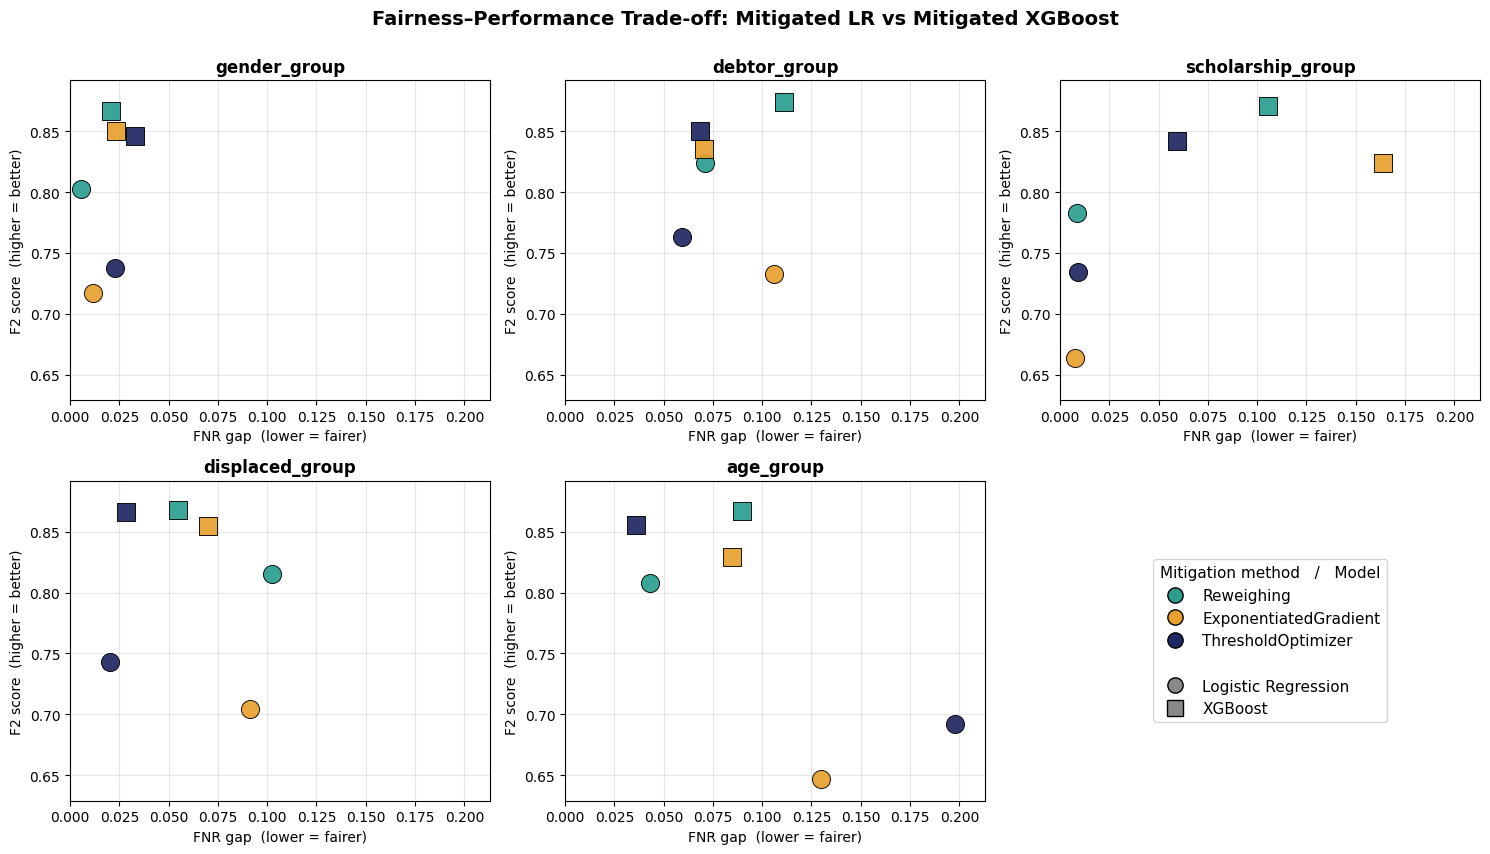

In [86]:
# ----- Comparison plot: F2 (y) vs FNR gap (x), 5 attributes, 6 method-model combos -----
# Better point = upper-left corner of each panel.
#   - low x (FNR gap)  -> fairer
#   - high y (F2)      -> stronger predictive performance
# Markers: model     ('o' = Logistic Regression,  's' = XGBoost)
# Colours: mitigation method

method_colors = {
    "Reweighing":            "#2A9D8F",
    "ExponentiatedGradient": "#E8A02E",
    "ThresholdOptimizer":    "#1E2761",
}
model_markers = {
    "Logistic Regression":   "o",
    "XGBoost":               "s",
}

x_min = mitigation_comparison_df['fnr_gap'].min()
x_max = mitigation_comparison_df['fnr_gap'].max()
y_min = mitigation_comparison_df['f2'].min()
y_max = mitigation_comparison_df['f2'].max()
x_pad = max(0.005, (x_max - x_min) * 0.08)
y_pad = max(0.005, (y_max - y_min) * 0.08)

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes_flat = axes.flatten()

for ax, attr in zip(axes_flat, sensitive_attrs):
    sub = mitigation_comparison_df[mitigation_comparison_df['attribute'] == attr]
    for _, row in sub.iterrows():
        ax.scatter(
            row['fnr_gap'], row['f2'],
            color=method_colors[row['mitigation']],
            marker=model_markers[row['model']],
            s=170, edgecolor='black', linewidth=0.7, alpha=0.92,
            zorder=3,
        )
    ax.set_title(attr, fontsize=12, fontweight='bold')
    ax.set_xlabel("FNR gap  (lower = fairer)", fontsize=10)
    ax.set_ylabel("F2 score  (higher = better)", fontsize=10)
    ax.grid(True, alpha=0.3, zorder=1)
    ax.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

axes_flat[-1].axis('off')

from matplotlib.lines import Line2D
legend_handles = []
for method, color in method_colors.items():
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markeredgecolor='black', markersize=11, label=method)
    )
legend_handles.append(Line2D([0], [0], color='none', label=' '))
for model, marker in model_markers.items():
    legend_handles.append(
        Line2D([0], [0], marker=marker, color='w', markerfacecolor='#888',
               markeredgecolor='black', markersize=11, label=model)
    )

axes_flat[-1].legend(
    handles=legend_handles,
    loc='center',
    fontsize=11,
    frameon=True,
    title='Mitigation method   /   Model',
    title_fontsize=11,
)

fig.suptitle(
    "Fairness–Performance Trade-off: Mitigated LR vs Mitigated XGBoost",
    fontsize=14, fontweight='bold', y=1.00
)
fig.tight_layout()
plt.show()


### Results — mitigated LR vs. mitigated XGBoost

The plot above shows the fairness–performance trade-off for every combination of model (LR vs. XGBoost), mitigation strategy (Reweighing, ExponentiatedGradient, ThresholdOptimizer) and sensitive attribute. **Lower on the x-axis** means a smaller FNR gap across groups (fairer); **higher on the y-axis** means a stronger F2 score (better predictive performance). The ideal point is therefore the upper-left corner of each panel. Circles are Logistic Regression mitigations; squares are XGBoost mitigations.

**Three patterns stand out.**

**1. XGBoost mitigations dominate on F2 across every attribute.** Every square sits in the upper region of every panel (F2 between roughly `0.82` and `0.88`), while every circle sits lower (F2 between roughly `0.65` and `0.83`). The predictive strength of XGBoost is preserved through all three mitigation strategies — the fairness step does not collapse XGBoost's performance the way it pulls down LR's `ExponentiatedGradient` and `ThresholdOptimizer`.

**2. Reweighing's near-parity win on LR does not fully transfer to XGBoost, *and* on LR itself it is achieved partly by flagging the majority of students.** On gender, LR + Reweighing produces an FNR gap of `0.006` and XGBoost + Reweighing matches it (`0.021`). But on scholarship, where LR + Reweighing also looks like near-parity (`0.008`), XGBoost + Reweighing widens the gap to `0.105`; debtor widens similarly. The intuition is that XGBoost is a more flexible model and can partially absorb the reweighted training distribution, recovering its original group-conditional predictions, where the constrained LR cannot. Reweighing therefore "bites" harder on the simpler model. In addition, the LR + Reweighing operating point has a selection rate of `0.6`–`0.85` across groups, so the headline near-parity is partly the result of flagging the majority of students rather than of genuinely equal predictions per group.

**3. ThresholdOptimizer is the most robust strategy on XGBoost.** It closes the FNR gap to small values on most attributes while keeping F2 above `0.84`. The most striking improvement is on `age_group`, where LR + ThresholdOptimizer left a large FNR gap (`~0.20`) but XGBoost + ThresholdOptimizer reduces it to roughly `0.03` with F2 of about `0.85`. ExponentiatedGradient on XGBoost also performs much better than its LR counterpart — F2 in the `0.82`–`0.86` range — but its FNR gaps are less consistent than ThresholdOptimizer's.

**Implication for deployment.** The earlier scoping limitation — mitigation tested only on Logistic Regression — is now closed, and the picture is genuinely different on XGBoost. **XGBoost + ThresholdOptimizer** is the most defensible deployment choice: it gives the highest F2, the smallest and most consistent FNR gaps across attributes, and the simplest mitigation to maintain (it adjusts thresholds post-hoc, leaving the base model untouched). It also does not rely on the high-selection-rate operating point that makes LR + Reweighing's near-parity look better than it really is. Scholarship remains the hardest attribute on XGBoost for every strategy, which is consistent with the structural finding from the original audit: the scholarship signal is so predictive that the model resists fairness corrections on it.


# XGBoost Post-hoc Explainability

To complement the fairness analysis, we explain the **black-box XGBoost model** with two post-hoc methods:
- **LIME** for a local surrogate explanation of one prediction
- **SHAP** for local and global feature-attribution analysis

We also compute a **faithfulness metric** so the explanations are not only visual, but also evaluated against actual model behaviour.


In [87]:
# Imports for post-hoc explainability
try:
    from lime.lime_tabular import LimeTabularExplainer
    import shap
    from aix360.metrics import faithfulness_metric
except ImportError as e:
    raise ImportError(
        "Required explainability packages are missing for the XGBoost post-hoc section."
    ) from e


We reuse the saved `XGB` model and the held-out `X_test` set. 


In [88]:
# Prepare named test data for explainability
Predictors = list(X_test.columns)
X_test_flat = pd.DataFrame(X_test.values, columns=Predictors)
Y_test_flat = Y_test.reset_index(drop=True)

# Use one concrete held-out student for local explanation
instance_idx = 2
instance = X_test_flat.iloc[instance_idx].values
class_names = ["Graduate", "Dropout"]

print(f"Explaining XGBoost prediction for held-out instance {instance_idx}")
display(X_test_flat.iloc[[instance_idx]])
print(f"True label: {class_names[int(Y_test_flat.iloc[instance_idx])]}")
print(f"Predicted probabilities: {XGB.predict_proba(instance.reshape(1, -1))[0]}")


Explaining XGBoost prediction for held-out instance 2


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP
2,1.0,1.0,1.0,2.0,1.0,1.0,1.0,13.0,14.0,8.0,8.0,1.0,0.0,0.0,1.0,0.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.9,-0.3,0.79


True label: Graduate
Predicted probabilities: [0.75462186 0.2453781 ]


We are explaining one held-out student. In the saved run, the true label is `Graduate`, and the XGBoost model predicts roughly `75.5%` probability of `Graduate` and `24.5%` probability of `Dropout`, so this is a moderately confident non-dropout prediction rather than an extreme borderline case.




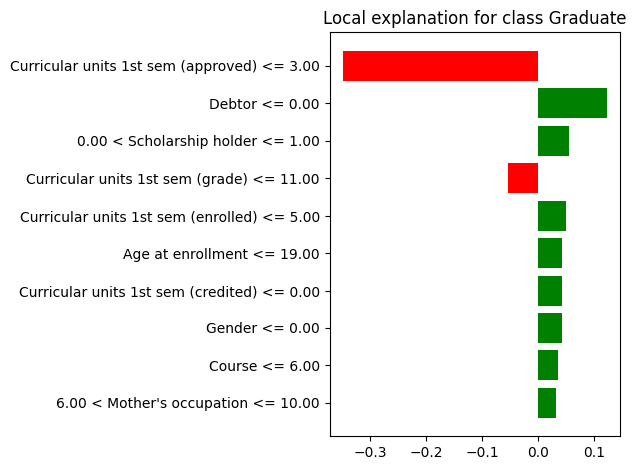

,feature,lime_weight
22,Curricular units 1st sem (approved),-0.349042
13,Debtor,0.122255
16,Scholarship holder,0.054825
23,Curricular units 1st sem (grade),-0.054580
20,Curricular units 1st sem (enrolled),0.050075
17,Age at enrollment,0.041768
19,Curricular units 1st sem (credited),0.041419
15,Gender,0.041391
3,Course,0.035641
9,Mother's occupation,0.031438


In [89]:
# Local explanation with LIME
lime_explainer = LimeTabularExplainer(
    X_test_flat.values,
    feature_names=Predictors,
    class_names=class_names,
    discretize_continuous=True,
    random_state=random_seed,
)

lime_exp = lime_explainer.explain_instance(
    instance,
    XGB.predict_proba,
    num_features=10,
    top_labels=1,
)
predicted_class = int(XGB.predict(instance.reshape(1, -1))[0])

lime_fig = lime_exp.as_pyplot_figure(label=predicted_class)
plt.tight_layout()
plt.show()

lime_pairs = lime_exp.local_exp[predicted_class]
lime_coefs = np.zeros(instance.shape[0])
for feature_idx, weight in lime_pairs:
    lime_coefs[feature_idx] = weight

lime_local_df = pd.DataFrame({
    "feature": Predictors,
    "lime_weight": lime_coefs,
    "abs_lime_weight": np.abs(lime_coefs),
}).sort_values("abs_lime_weight", ascending=False).head(10)
display(lime_local_df[["feature", "lime_weight"]])


In the saved run, for this one student the strongest local LIME feature is `Curricular units 1st sem (approved)`, followed by `Debtor`, `Scholarship holder`, `Curricular units 1st sem (grade)`, and `Curricular units 1st sem (enrolled)`. This means the local surrogate model sees first-semester academic progress as the main reason for the prediction, with financial and demographic variables playing a secondary role.

This is fine because our model is meant to predict after semester 1 and before semester 2.

SHAP provides a model-aware explanation for XGBoost. We use it in two ways:
- **local SHAP values** for the same individual prediction
- **global mean absolute SHAP values** to show the most influential features overall


,feature,shap_value
22,Curricular units 1st sem (approved),2.033402
20,Curricular units 1st sem (enrolled),-0.961240
3,Course,-0.775093
16,Scholarship holder,-0.567667
25,Unemployment rate,0.356840
23,Curricular units 1st sem (grade),0.250608
14,Tuition fees up to date,-0.199483
15,Gender,-0.178874
7,Mother's qualification,-0.154706
1,Application mode,-0.142844


,feature,mean_abs_shap
22,Curricular units 1st sem (approved),1.679123
14,Tuition fees up to date,0.427965
23,Curricular units 1st sem (grade),0.354178
20,Curricular units 1st sem (enrolled),0.296458
16,Scholarship holder,0.228819
3,Course,0.228598
17,Age at enrollment,0.214521
13,Debtor,0.206221
25,Unemployment rate,0.186495
15,Gender,0.167143


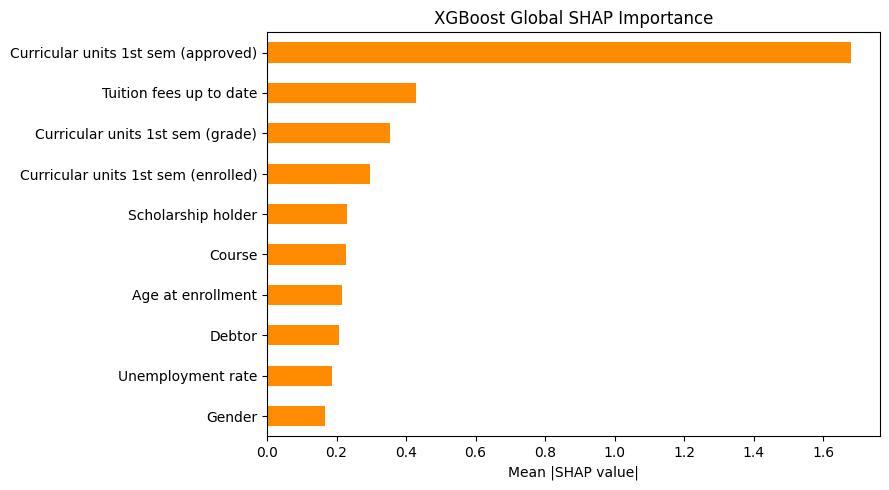

In [90]:
# SHAP explanations for the XGBoost model
shap_explainer = shap.TreeExplainer(XGB.named_steps['xgb'])
shap_values = shap_explainer.shap_values(X_test_flat)
shap_coefs = np.asarray(shap_values[instance_idx])

shap_local_df = pd.DataFrame({
    "feature": Predictors,
    "shap_value": shap_coefs,
    "abs_shap_value": np.abs(shap_coefs),
}).sort_values("abs_shap_value", ascending=False).head(10)
display(shap_local_df[["feature", "shap_value"]])

global_shap_df = pd.DataFrame({
    "feature": Predictors,
    "mean_abs_shap": np.abs(np.asarray(shap_values)).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
display(global_shap_df.head(10))

ax = global_shap_df.head(10).sort_values("mean_abs_shap").plot.barh(
    x="feature", y="mean_abs_shap", legend=False, figsize=(9, 5), color="darkorange"
)
ax.set_title("XGBoost Global SHAP Importance")
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


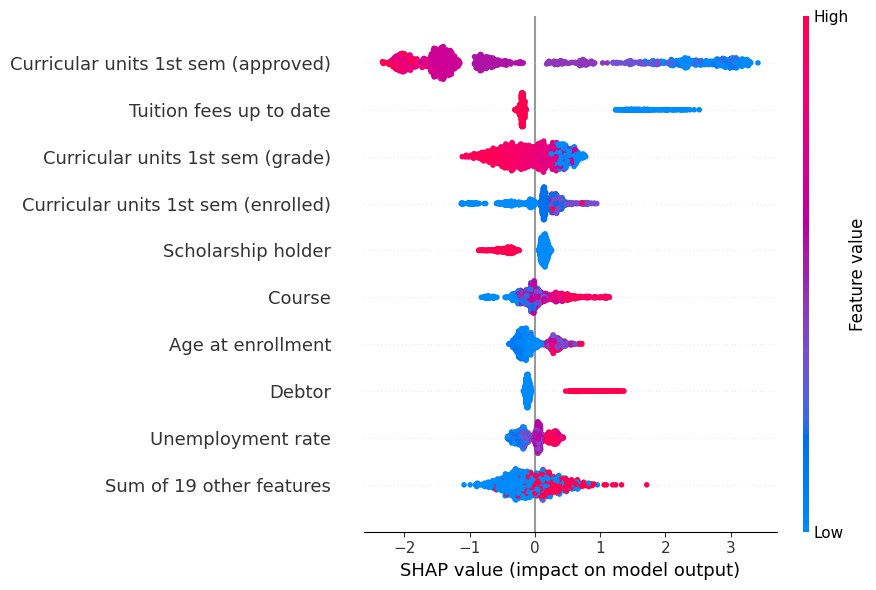

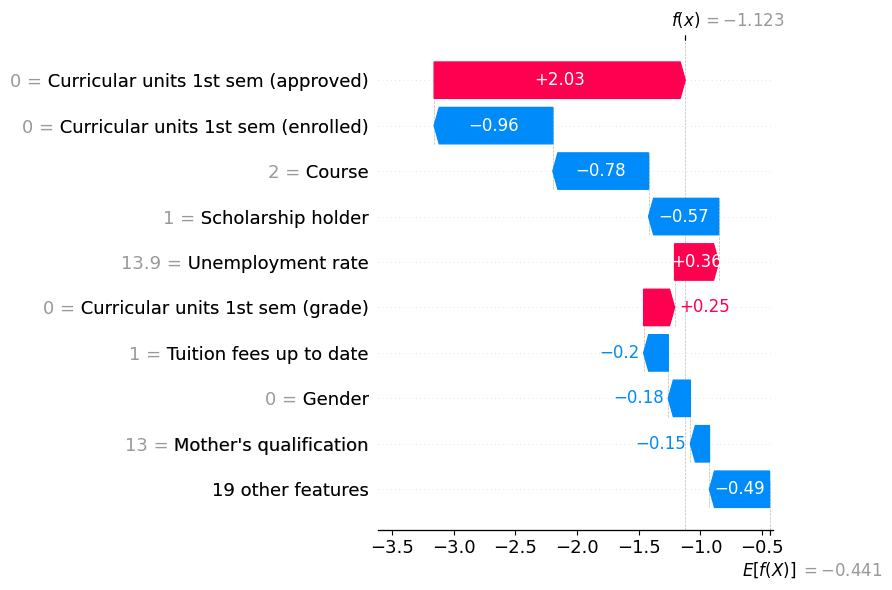

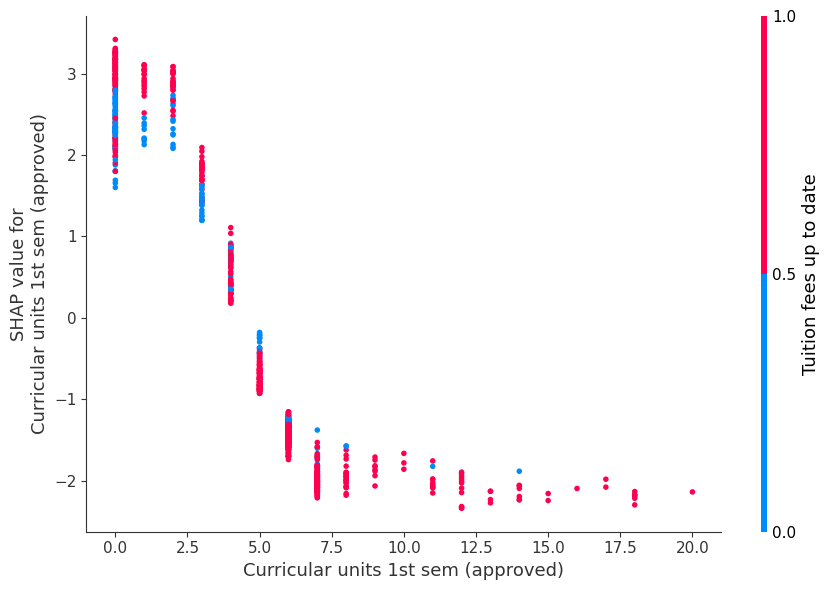

In [91]:
# Additional SHAP visualisations
important_feature = "Curricular units 1st sem (approved)"
interaction_feature = "Tuition fees up to date" if "Tuition fees up to date" in Predictors else "auto"

try:
    shap_explanation = shap_explainer(X_test_flat)
    shap_matrix = np.asarray(shap_explanation.values)

    shap.plots.beeswarm(shap_explanation, max_display=10, show=False)
    plt.gcf().set_size_inches(9, 6)
    plt.tight_layout()
    plt.show()

    shap.plots.waterfall(shap_explanation[instance_idx], max_display=10, show=False)
    plt.gcf().set_size_inches(9, 6)
    plt.tight_layout()
    plt.show()

    if important_feature in X_test_flat.columns:
        shap.dependence_plot(
            important_feature,
            shap_matrix,
            X_test_flat,
            feature_names=Predictors,
            interaction_index=interaction_feature,
            show=False,
        )
        plt.gcf().set_size_inches(9, 6)
        plt.tight_layout()
        plt.show()
except Exception:
    shap_matrix = np.asarray(shap_values)

    shap.summary_plot(shap_matrix, X_test_flat, show=False, max_display=10)
    plt.gcf().set_size_inches(9, 6)
    plt.tight_layout()
    plt.show()

    base_value = shap_explainer.expected_value
    if isinstance(base_value, (list, tuple, np.ndarray)):
        base_value = np.asarray(base_value).reshape(-1)[0]

    local_explanation = shap.Explanation(
        values=shap_matrix[instance_idx],
        base_values=base_value,
        data=X_test_flat.iloc[instance_idx].values,
        feature_names=Predictors,
    )
    shap.plots.waterfall(local_explanation, max_display=10, show=False)
    plt.gcf().set_size_inches(9, 6)
    plt.tight_layout()
    plt.show()

    if important_feature in X_test_flat.columns:
        shap.dependence_plot(
            important_feature,
            shap_matrix,
            X_test_flat,
            feature_names=Predictors,
            interaction_index=interaction_feature,
            show=False,
        )
        plt.gcf().set_size_inches(9, 6)
        plt.tight_layout()
        plt.show()


**Beeswarm / summary plot.** This plot confirms that `Curricular units 1st sem (approved)` is the dominant feature across the dataset, not just for one student. It also adds direction: low approved-unit values are associated with positive SHAP values, meaning they push the model toward higher dropout risk, while high approved-unit values push predictions in the opposite direction. The same broad pattern appears for other academic and financial variables, especially `Curricular units 1st sem (grade)` and `Tuition fees up to date`, which supports a coherent model story rather than a random ranking of inputs.

**Local waterfall plot.** For the selected held-out student, the waterfall plot shows that `Curricular units 1st sem (approved)` is the single strongest contributor in the local explanation. Other variables such as `Course`, `Scholarship holder`, `Curricular units 1st sem (enrolled)`, and `Tuition fees up to date` also influence the prediction, but with much smaller effects. This is useful because it shows how a few key factors combine to produce the final prediction for one concrete case.

**Dependence plot for `Curricular units 1st sem (approved)`.** This plot shows a very strong monotonic relationship: students with few approved units have strongly positive SHAP values, meaning this feature increases predicted dropout risk, while students with many approved units have strongly negative SHAP values, meaning this feature reduces predicted dropout risk. The main pattern is driven by approved units themselves, and the color coding with `Tuition fees up to date` suggests only a limited secondary interaction compared with the very strong direct effect of approved units.







Finally, we compare **faithfulness** for LIME and SHAP. Higher faithfulness means the explanation ranking is more consistent with how the model’s predicted probability actually changes when important features are removed.


Faithfulness Metric Comparison (Instance 2):
 - LIME faithfulness: 0.0680
 - SHAP faithfulness: -0.2018


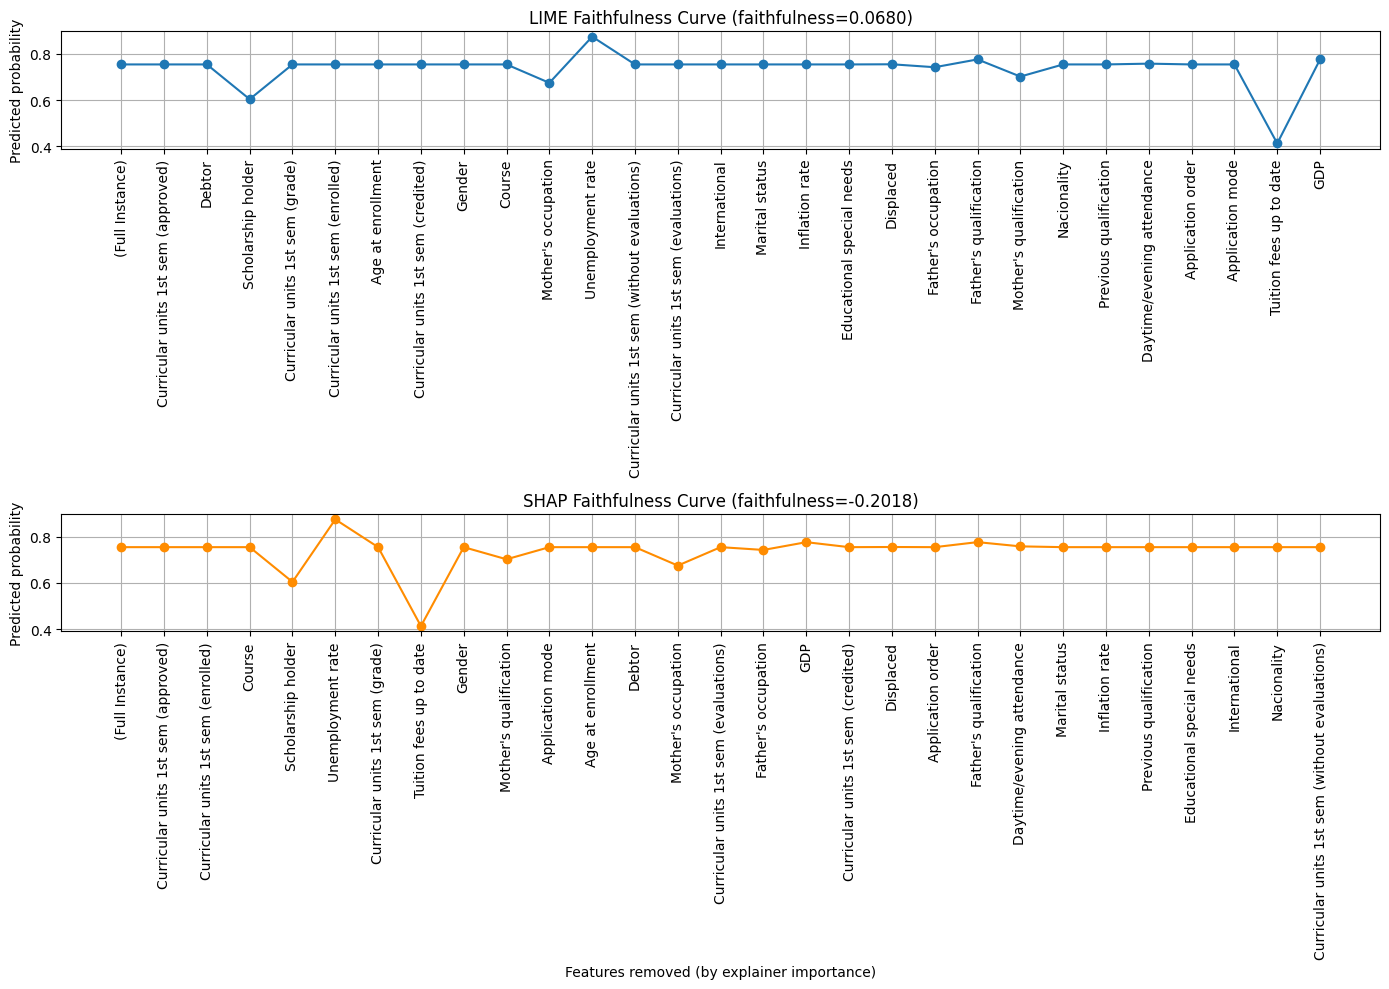

In [92]:
# Faithfulness comparison
base = np.zeros(instance.shape[0])
faithfulness_lime = faithfulness_metric(XGB, instance.flatten(), lime_coefs, base)
faithfulness_shap = faithfulness_metric(XGB, instance.flatten(), shap_coefs, base)

print(f"Faithfulness Metric Comparison (Instance {instance_idx}):")
print(f" - LIME faithfulness: {faithfulness_lime:.4f}")
print(f" - SHAP faithfulness: {faithfulness_shap:.4f}")

def faithfulness_curve(model, x, coefs, base, feature_names):
    pred_class = int(np.argmax(model.predict_proba(x.reshape(1, -1)), axis=1)[0])
    order = np.argsort(-np.abs(coefs))
    pred_probs = np.zeros(x.shape[0])
    for idx, feature_idx in enumerate(order):
        x_copy = x.copy()
        x_copy[feature_idx] = base[feature_idx]
        pred_probs[idx] = model.predict_proba(x_copy.reshape(1, -1))[0, pred_class]
    baseline_pred = model.predict_proba(x.reshape(1, -1))[0, pred_class]
    pred_probs = np.insert(pred_probs, 0, baseline_pred)
    labels = ["(Full Instance)"] + [feature_names[i] for i in order]
    return pred_probs, labels

lime_probs, lime_features = faithfulness_curve(XGB, instance, lime_coefs, base, Predictors)
shap_probs, shap_features = faithfulness_curve(XGB, instance, shap_coefs, base, Predictors)

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharey=True)

axs[0].plot(lime_probs, marker='o')
axs[0].set_title(f"LIME Faithfulness Curve (faithfulness={faithfulness_lime:.4f})")
axs[0].set_ylabel('Predicted probability')
axs[0].set_xticks(np.arange(len(lime_features)))
axs[0].set_xticklabels(lime_features, rotation=90)
axs[0].grid(True)

axs[1].plot(shap_probs, marker='o', color='darkorange')
axs[1].set_title(f"SHAP Faithfulness Curve (faithfulness={faithfulness_shap:.4f})")
axs[1].set_xlabel('Features removed (by explainer importance)')
axs[1].set_ylabel('Predicted probability')
axs[1].set_xticks(np.arange(len(shap_features)))
axs[1].set_xticklabels(shap_features, rotation=90)
axs[1].grid(True)

plt.tight_layout()
plt.show()


 In the saved run, `LIME` has faithfulness around `0.068`, while `SHAP` is negative at about `-0.202`. These are weak results, so this part of the analysis does **not** provide strong evidence that the perturbation-based feature rankings are closely tracking the model’s probability changes for this instance.

 A negative SHAP faithfulness score does **not** mean that SHAP is simply "wrong." More carefully, it suggests that the **perturbation procedure used in this metric** does not align especially well with how TreeExplainer attributes importance in an XGBoost model. Here we are testing faithfulness by replacing one feature at a time with an all-zero baseline and observing how the predicted probability moves. That is a fairly artificial intervention for a tree-based model with encoded categorical and academic-performance variables, so the resulting probability changes may not match SHAP’s additive contribution logic very closely. The safest interpretation is therefore that this faithfulness check is a rough diagnostic rather than a decisive evaluation of explanation quality.



# Model Card

## Model Overview
This project develops and evaluates a **student dropout risk model** designed for use **after semester 1 and before semester 2 begins**. The operational goal is to help a university identify students who may be at risk of dropping out early enough for supportive intervention, such as tutoring, advising, or financial guidance. The modelling problem is framed as a **binary classification task** after removing the `Enrolled` class: `1 = Dropout` and `0 = Graduate`.

Two predictive model families are used in the notebook. `Logistic Regression` serves as the **interpretable baseline**, because it allows coefficient-level interpretation and is compatible with the fairness-mitigation workflow. `XGBoost` serves as the **higher-capacity black-box comparator**, used both to test whether a more expressive nonlinear model can deliver stronger predictive performance and — in the extended mitigation section — to test whether the three fairness mitigation strategies transfer to the model that would actually be deployed.

## Model Details
The Logistic Regression pipeline is trained on a reduced set of statistically significant pre-semester-2 variables after iterative VIF filtering, which is intended to stabilise coefficients and keep the baseline explainable. XGBoost is trained on the broader pre-semester-2 predictor set with conservative hyperparameters, validation-based early stopping, subsampling, and regularisation to reduce overfitting.

The notebook applies three fairness mitigation strategies to **both** Logistic Regression and XGBoost:
- **Reweighing** as a pre-processing method
- **ExponentiatedGradient** as an in-processing method
- **ThresholdOptimizer** as a post-processing method

This means the project has three distinct decision layers: a comparison of predictive models (`Logistic Regression` versus `XGBoost`); a fairness-performance comparison of mitigation strategies on the interpretable baseline; and the same comparison repeated on `XGBoost` so the deployment recommendation can rest on the model that would actually be used.

## Intended Use
The model is intended for **supportive early-warning intervention**, not for punishment, exclusion, or automated adverse decisions. A university could use the predictions to prioritise additional outreach to students who appear at elevated dropout risk before semester 2. In that setting, the model should be used as a **decision-support tool** for staff, not as a fully autonomous replacement for human judgement.

This intended use is important because it shapes the project's metric choices. In a supportive intervention context, the main harm is **missing a student who truly needs help**. For that reason, the notebook prioritises **recall** and especially **False Negative Rate (FNR)**, both overall and across sensitive groups.

## Out-of-Scope or Inappropriate Use
This system should **not** be used as the sole basis for denying educational opportunities, limiting student access to resources, or inferring causal explanations about why a student may drop out. The model captures statistical associations in the observed data, not causal relationships. It should also not be interpreted as a moral or behavioural judgement about students; several influential variables are structural or context-dependent, including financial status, scholarship access, and first-semester performance.

## Data
The dataset is the student performance and dropout dataset used throughout the project. The notebook first applies a project-specific cleaning and framing step:
- removes `Enrolled`
- creates the binary target `target`
- drops all `2nd sem` variables to avoid future-information leakage
- creates readable fairness-group variables for the audit

The result is a modelling dataset of `3,630` students, with `2,209` graduates and `1,421` dropouts in the saved run. Because the university's intervention point is after semester 1, first-semester variables such as approved units and grades are considered valid inputs, although the notebook explicitly recognises that some of them are **outcome-adjacent** and therefore especially powerful signals.

## Sensitive Attributes and Fairness Scope
The fairness analysis focuses on the following selected attributes:
- `gender_group`
- `debtor_group`
- `scholarship_group`
- `displaced_group`
- `age_group`

These attributes are not all equally predictive in the statistical sense, but they are relevant to the project's fairness framing because they capture groups that may be differentially underflagged by the model. The notebook's fairness concern is not generic demographic parity; it is specifically the risk that some groups will experience **higher false negative rates**, meaning that at-risk students in those groups would be less likely to receive support.

## Performance Metrics
The notebook uses several standard classification metrics, but they serve different purposes:
- **Recall** is central because false negatives are especially costly in this intervention setting.
- **Precision** matters because support resources are limited, so overly broad flagging is also undesirable.
- **F1** summarises the precision-recall balance.
- **F2** is used for **operational threshold selection**, because it weights recall more heavily than precision and therefore aligns better with the project goal.
- **ROC-AUC** is used as a ranking-quality metric for baseline model comparison.
- **False Negative Rate (FNR)** and **FNR difference across groups** are the main fairness metrics.

This combination of metrics reflects the fact that the project is not only about building the most accurate classifier, but also about evaluating who the model fails to flag. Where Reweighing achieves near-parity FNRs by adopting a high selection-rate operating point, the notebook reports the supporting selection-rate and FPR numbers so the trade-off remains visible.

## Baseline Model Findings
The baseline modelling stage shows that `XGBoost` is the strongest **pure predictive** model in the notebook. It outperforms Logistic Regression on the main predictive metrics and remains stronger after recall-oriented threshold selection. This suggests that the dropout problem contains nonlinearities and interaction effects that are not fully captured by a simpler linear decision boundary.

At the same time, the baseline fairness audit shows that even a stronger predictive model does not automatically eliminate fairness concerns. Logistic Regression, when evaluated at the operational threshold, shows substantial group differences in false negative rate, especially for scholarship status, age, displaced status, and gender. XGBoost reduces several of these disparities, but not all, and `debtor_group` even widens. So the project's main lesson at this stage is that better predictive performance helps but does not remove the need for explicit fairness analysis.

## Mitigation Findings
The mitigation stage now compares all three strategies on **both** Logistic Regression and XGBoost.

**On Logistic Regression**, `Reweighing` produces the smallest FNR gaps for the binary attributes (gender `0.006`, scholarship `0.008`, age `0.043`). With its base estimator correctly class-weighted, `ExponentiatedGradient` is competitive with Reweighing on those same binary attributes (scholarship `0.008`, gender `0.012`), but its overall `F2` is lower (`0.65`–`0.73`), reflecting a genuine fairness-performance trade-off when parity is enforced during training. `ThresholdOptimizer` is strongest for `debtor_group` and `displaced_group`, reducing those FNR gaps to `0.060` and `0.020`. Reweighing's near-parity numbers should be read with one caveat: at the F2-selected threshold of `0.25`, the model flags the majority of students (selection rate `0.6`–`0.85` and FPR `0.4`–`0.6` per group), so part of the FNR equalisation is achieved by spreading the alarm widely rather than by ranking students more equally per group.

**On XGBoost**, all three mitigations preserve XGBoost's predictive advantage (`F2` between roughly `0.82` and `0.88`). `ThresholdOptimizer` on XGBoost stands out for closing the FNR gap to small values on most attributes — including a dramatic improvement on `age_group` from `0.20` (LR + ThresholdOptimizer) to about `0.03` (XGB + ThresholdOptimizer) — without the high-selection-rate side-effect of Reweighing. Reweighing's near-parity on scholarship does **not** transfer cleanly from LR to XGBoost: XGBoost is flexible enough to partially absorb the reweighted training distribution and reconstruct its original group-conditional predictions.

## Explainability Findings
The post-hoc explainability section focuses on the XGBoost model, since it is the strongest predictive model but also the least directly interpretable. The notebook uses:
- **LIME** for a local surrogate explanation of one held-out student
- **SHAP** for both local and global feature attribution
- additional SHAP visualisations including a beeswarm plot, waterfall plot, and dependence plot
- a faithfulness comparison between LIME and SHAP

Across local and global explanations, the strongest and most consistent finding is that **`Curricular units 1st sem (approved)` is the dominant driver of the XGBoost model**. Other important signals include tuition-fee status, first-semester grade, first-semester enrolled units, scholarship status, course, age at enrolment, and debtor status. This is substantively meaningful for the project because it shows that the model relies heavily on early academic progression, with financial and demographic variables acting as secondary adjustments.

The notebook also treats the faithfulness results cautiously. The saved run shows weak LIME faithfulness and a negative SHAP faithfulness score, but the interpretation explicitly notes that this does not imply SHAP is simply wrong. Instead, it suggests that the perturbation procedure used in that metric may not align especially well with TreeExplainer's additive logic for a tree-based model.

## Limitations
Several limitations should be stated clearly.

First, the model is built on a single dataset and has not been validated on a different institution, region, or cohort. Its performance and fairness properties may therefore change under deployment elsewhere.

Second, the strongest predictive signals come from **first-semester academic performance**, especially approved units and grade. These are valid features under the project timing because the intervention occurs after semester 1, but they are still very close to the eventual outcome and should be acknowledged as outcome-adjacent.

Third, fairness estimates depend on group size. Some attributes may be easier to estimate reliably than others, and descriptive group imbalance should always be considered when interpreting the audit.

Fourth, `Reweighing`'s near-parity FNRs on Logistic Regression are achieved at a high selection-rate operating point. This is faithful to the project's recall-first harm model, but it is a different kind of fairness than per-group calibrated predictions and should be reported with that context.

Finally, the post-hoc explanation metrics are informative but not definitive. LIME and SHAP show coherent feature-importance stories, but the faithfulness diagnostic is sensitive to the perturbation baseline and should be interpreted as a rough robustness check rather than a final verdict on explanation quality.

## Ethical Considerations
This model is designed for a supportive educational use case, which is ethically preferable to punitive deployment, but it still raises important concerns. If deployed uncritically, a model of this kind could reinforce structural disadvantages by systematically underflagging some groups or by over-relying on variables that encode existing academic and financial inequalities.

The notebook addresses this by making fairness analysis central rather than optional. It does not treat overall accuracy as sufficient, and it explicitly compares mitigation methods to reduce unequal underflagging — on both the interpretable baseline and on the deployment model. That said, fairness mitigation does not remove all ethical risk. Human oversight, careful communication to staff, and ongoing monitoring would still be necessary in a real application.

## Recommended Interpretation of the Project
The strongest overall conclusion from the notebook is not that one model solves both prediction and fairness perfectly. Instead, the project shows a more nuanced result:
- `XGBoost` is the strongest model when the main goal is predictive quality.
- `Logistic Regression` is the interpretable fairness baseline, and `LR + Reweighing` is its strongest mitigated form — with the caveat that the near-parity FNRs are paid for at a high selection-rate operating point.
- On the **deployment model**, the strongest mitigated configuration is **`XGBoost + ThresholdOptimizer`**: it preserves XGBoost's predictive performance, gives the most consistent FNR-gap reductions across attributes, and equalises the false-negative experience without relying on a flag-most-students operating point.
- `ExponentiatedGradient` is now competitive with Reweighing on binary attributes once its base estimator is class-weighted, but it pays a real F2 cost in this dataset.

So if the university's first priority is **pure predictive screening**, XGBoost is the best model in the notebook. If the priority is **mitigated and explainable decision support**, the LR baseline with Reweighing remains the most interpretable option, but the cleanest deployment-ready recommendation that the full mitigation evidence now supports is **`XGBoost` combined with `ThresholdOptimizer`** under explicit fairness monitoring.
